# IAA (Krippendorff's $\alpha$)

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from krippendorff import alpha
from numpy import dtype, ndarray
from tqdm import tqdm
from typing import Any, Literal

INPUT_DATA_PATH = os.path.join("../data", "students_teacher_gold.json")

In [2]:
def get_data(input_data_path: str = INPUT_DATA_PATH) -> list[list[dict[str, Any]]]:
    with open(input_data_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return [item.get("teacher_annotation_data", []) for item in data]

def get_annotators(input_data_path: str = INPUT_DATA_PATH) -> list[str]:
    data = get_data(input_data_path)
    
    annotators = set()
    for annotations in data:
        for annotation in annotations:
            id = annotation.get("annotator_id")
            if id is not None:
                annotators.add(id)

    return sorted(list(annotators))

def get_n_annotated_items(input_data_path: str = INPUT_DATA_PATH) -> int:
    return len(get_data(input_data_path))

def load_data_matrix(input_path: str = INPUT_DATA_PATH) -> ndarray[tuple[int, int], dtype[Any]]:
    """
    Load the gold JSON data and convert it into a matrix, where each row corresponds to an annotator and each column corresponds to an annotated item. The matrix contains the numeric representation of the annotations (1 for model A, -1 for model B, 0 for ties), and fills missing annotations with `NaN` values.
    The output matrix can be used to compute Krippendorff's alpha.
    """
    data = get_data(input_path)
    
    n_annotated_items = get_n_annotated_items(input_path)
    annotators = get_annotators(input_path)
    
    annotator_to_idx = {annotator: idx for idx, annotator in enumerate(annotators)}
    
    map_annotation_to_numeric = {
        "a": 1,
        "both_equal": 0,
        "b": -1
    }

    out_matrix = np.full((len(annotators), n_annotated_items), np.nan)
    
    for i, item in enumerate(data):
        for annotation in item:
            annotator_id = annotation.get("annotator_id")
            label = map_annotation_to_numeric.get(annotation.get("preferred_model", ""), None)
            
            if annotator_id is not None and annotator_id in annotator_to_idx and label is not None:
                out_matrix[annotator_to_idx[annotator_id], i] = label
    
    return out_matrix

In [3]:
# def compute_bootstrapped_alpha(data_matrix: np.ndarray, level_of_measurement: Literal['nominal', 'ordinal'] = 'nominal', value_domain: list = None, n_iterations: int = 20000, p_value: float = 0.05, seed: int | None = 2026) -> tuple[np.floating, np.float64, np.float64]:
#     """
#     Computes Krippendorff's alpha confidence intervals using the 
#     bootstrapping algorithm defined by K. Krippendorff (2006):
#     *"Bootstrapping Distributions for Krippendorff’s Alpha
#     for coding predefined units: single-valued c_alpha and multi-valued mv_alpha"*
    
#     Source: https://www.asc.upenn.edu/sites/default/files/2021-03/Algorithm%20for%20Bootstrapping%20a%20Distribution%20of%20Alpha.pdf
#     (Backup Archive:) https://web.archive.org/web/20260209232738/https://www.asc.upenn.edu/sites/default/files/2021-03/Algorithm%20for%20Bootstrapping%20a%20Distribution%20of%20Alpha.pdf
    
#     Based on the original metric: https://www.asc.upenn.edu/sites/default/files/2021-03/Computing%20Krippendorff's%20Alpha-Reliability.pdf
#     (Backup Archive:) https://web.archive.org/web/20260624173717/https://www.asc.upenn.edu/sites/default/files/2021-03/Computing%20Krippendorff's%20Alpha-Reliability.pdf
    
#     Returns:
    
#     A 3-tuple (observed alpha, lower bound of confidence interval, upper bound of confidence interval).
#     """
#     rng = np.random.default_rng(seed)
    
#     n_observers, n_items = data_matrix.shape

#     # -- Data preparation and parameters
    
#     # "Number of pairable values m_u"
#     m_u_list = np.sum(~np.isnan(data_matrix), axis=0)

#     # "The number N_o of unique pairs that contribute to alpha"
#     N_o = int(np.sum((m_u_list - 1) * m_u_list / 2))

#     # "n.. = sum(m_u)" (Total number of pairable values)
#     n_dotdot = np.sum(m_u_list)

#     if N_o == 0 or n_dotdot == 0:
#         raise ValueError("Not enough pairable data to compute alpha.")

#     # Calculate expected disagreement (D_e) from the observed data.
#     # We maintain "the generally more stable expected disagreement D_e from the observed data."
#     valid_values = data_matrix[~np.isnan(data_matrix)]
    
#     if value_domain is not None and type(value_domain) is list and len(value_domain) > 0:
#         # If a domain is provided, we use it to ensure that all categories are included in the counts, even if they have zero occurrences
#         unique_vals = np.array(value_domain)
#         # We order the unique values to ensure consistent ordering
#         unique_vals = np.sort(unique_vals) 
#         # We count the frequencies by forcing the inclusion of empty categories (0 occurrences)
#         counts = np.array([np.sum(valid_values == val) for val in unique_vals])
#     else:
#         # Otherwise, we compute the unique values and their counts from the observed data
#         unique_vals, counts = np.unique(valid_values, return_counts=True)
#         sort_idx = np.argsort(unique_vals)
#         unique_vals = unique_vals[sort_idx]
#         counts = counts[sort_idx]
    
#     K = len(unique_vals)
#     val_to_idx = {val: idx for idx, val in enumerate(unique_vals)}
    
#     # value_probs = counts / n_dotdot
    
#     # D_e = 1.0 - np.sum(value_probs ** 2) # Nominal metric D_e
    
#     # if D_e == 0:
#     #     raise ValueError("Reliability data have no variance whereby alpha = 1 - 0/0 = 0 by definition.")

#     # -- Parameterized distance matrix (delta^2)
    
#     delta_sq = np.zeros((K, K))
    
#     for i in range(K):
#         for j in range(K):
#             if level_of_measurement == 'nominal':
#                 # Nominal distance: 0 if identical, 1 if different
#                 delta_sq[i, j] = 0.0 if i == j else 1.0
#             elif level_of_measurement == 'ordinal':
#                 # Ordinal distance: relies on cumulative rank frequencies
#                 if i == j:
#                     delta_sq[i, j] = 0.0
#                 else:
#                     c, k = min(i, j), max(i, j)
#                     sum_counts = np.sum(counts[c:k + 1])
#                     dist = (sum_counts - counts[c] / 2.0 - counts[k] / 2.0)
#                     delta_sq[i, j] = dist ** 2
#             else:
#                 raise ValueError(f"Unsupported level of measurement: {level_of_measurement}")
    
#     # -- Universal expected disagreement (D_e)
    
#     D_e = 0.0
#     for i in range(K):
#         for j in range(K):
#             D_e += counts[i] * counts[j] * delta_sq[i, j]
#     D_e /= n_dotdot * (n_dotdot - 1)
    
#     if D_e == 0:
#         raise ValueError("Reliability data have no variance (D_e = 0).")

#     # -- Deviations array creation
    
#     E_list = []
#     unit_slices: list[tuple[int, int]] = [] # (start, end) per item with m_u >= 2
    
#     # "Create a list of N_o items"
#     for u in range(n_items):
#         unit_data = data_matrix[:, u]
#         unit_vals = unit_data[~np.isnan(unit_data)]
#         m_u = len(unit_vals)

#         start = len(E_list)

#         if m_u >= 2:
#             for i in range(m_u):
#                 for j in range(i + 1, m_u):
#                     # "metric delta^2" (For nominal: 0 if c == k, else 1)
#                     idx1 = val_to_idx[unit_vals[i]]
#                     idx2 = val_to_idx[unit_vals[j]]
                    
#                     d_sq = delta_sq[idx1, idx2]
                    
#                     # "The r-th out of N_o possible deviations E(r) from alpha=1 is:"
#                     # E(r) = 2 * (metric delta^2) / (n.. * D_e)
#                     E_r = 2.0 * d_sq / (n_dotdot * D_e)
#                     E_list.append(E_r)
#         end = len(E_list)
#         unit_slices.append((start, end))

#     E_array = np.array(E_list)
    
#     assert len(E_array) == N_o, f"Expected {N_o} deviations, but got {len(E_array)}."

#     # -- Deterministic alpha computation (observed alpha)
    
#     alpha_observed = 1.0
#     for u, (start, end) in enumerate(unit_slices):
#         m_u = m_u_list[u]
#         if m_u >= 2:
#             alpha_observed -= E_array[start:end].sum() / (m_u - 1)

#     # -- Bootstrapping algorithm

#     pair_counts = np.array([end - start for start, end in unit_slices])
#     total_pairs = pair_counts.sum()
    
#     # One big draw instead of drawing one by one to improve performance
#     all_r = rng.integers(0, N_o, size=(n_iterations, total_pairs))
#     all_E = E_array[all_r]

#     # # "Set the integer array n_alpha = 0"
#     # # Note: We use a raw array to store exact alphas for precise percentile computation
#     # bootstrapped_alphas = np.zeros(n_iterations)

#     # # "Do X times" (X = 20,000 suggested)
#     # for x in range(n_iterations):
        
#     #     # "alpha = 1"
#     #     alpha = 1.0

#     #     # "Do u = 1, N_u"
#     #     for u in range(n_items):
#     #         m_u = m_u_list[u]
#     #         if m_u >= 2:
#     #             n_pairs_in_u = int((m_u - 1) * m_u / 2)

#     #             # "Do (m_u - 1)m_u / 2 times (= The number of unique pairs in the u-th unit)"
#     #             for _ in range(n_pairs_in_u):
                    
#     #                 # "Pick a random integer 1 <= r <= N_o (uniform distribution)"
#     #                 # Note: Python is 0-indexed, so 0 <= r < N_o
#     #                 r = rng.integers(0, N_o)

#     #                 # "alpha <- alpha - E(r) / (m_u - 1)"
#     #                 alpha -= E_array[r] / (m_u - 1)

#     #     # "If alpha < -1: n_-1 = n_-1 + 1"
#     #     if alpha < -1.0:
#     #         alpha = -1.0

#     #     bootstrapped_alphas[x] = alpha

#     bootstrapped_alphas = np.full(n_iterations, 1.0)
#     col = 0
#     for u, (start, end) in enumerate(unit_slices):
#         m_u = m_u_list[u]
#         n_pairs_in_u = end - start
#         if m_u >= 2:
#             chunk = all_E[:, col:col + n_pairs_in_u].sum(axis=1)
#             bootstrapped_alphas -= chunk / (m_u - 1)
#         col += n_pairs_in_u
        
#     bootstrapped_alphas = np.clip(bootstrapped_alphas, -1.0, None)  # Ensure alpha >= -1

#     # -- Extracting confidence intervals
    
#     # "The confidence interval: -1 <= alpha_smallest <= alpha <= alpha_largest <= 1"
#     # "for a chosen level p of statistical significance (two-tailed)"
    
#     # "min >= 1 - p"
#     # "max <= p / 2"
#     lower_percentile = (p_value / 2.0) * 100
#     upper_percentile = (1.0 - p_value / 2.0) * 100

#     alpha_smallest = np.percentile(bootstrapped_alphas, lower_percentile)
#     alpha_largest = np.percentile(bootstrapped_alphas, upper_percentile)

#     print(f"Observed Alpha : {alpha_observed:.3f}")
#     print(f"Confidence Interval : [{alpha_smallest:.3f}, {alpha_largest:.3f}]")

#     return alpha_observed, alpha_smallest, alpha_largest

In [4]:
# print("Krippendorff's alpha:", alpha(load_data_matrix(INPUT_DATA_PATH), value_domain=[-1, 0, 1], level_of_measurement="ordinal"))
# compute_bootstrapped_alpha(load_data_matrix(INPUT_DATA_PATH), level_of_measurement="ordinal", value_domain=[-1, 0, 1], n_iterations=20000, p_value=0.05, seed=2026)

In [5]:
def compute_alpha_with_ci(
    data_matrix: np.ndarray,
    level_of_measurement: Literal['nominal', 'ordinal'] = 'nominal', 
    value_domain: list = None,
    n_iterations: int = 2000,
    p_value: float = 0.05,
    seed: int = 2026
) -> tuple[float, float, float]:
    """
    Computes Krippendorff's alpha and its confidence intervals using non-parametric bootstrapping on the units (columns) of the data matrix.
    """
    rng = np.random.default_rng(seed)
    n_annotators, n_items = data_matrix.shape

    # -- Computing the observed alpha
    try:
        alpha_observed = alpha(
            reliability_data=data_matrix,
            level_of_measurement=level_of_measurement,
            value_domain=value_domain
        )
    except ValueError as e:
        raise ValueError(f"Could not compute observed alpha: {e}")

    # -- Bootstrapping on the items (columns)
    bootstrapped_alphas = []

    # Vectorized generation of indices to speed up the loop
    # Matrix of (n_iterations, n_items) containing the randomly drawn indices
    all_resampled_indices = rng.choice(n_items, size=(n_iterations, n_items), replace=True)

    for i in tqdm(range(n_iterations), desc="Bootstrapping"):
        indices = all_resampled_indices[i]
        resampled_matrix = data_matrix[:, indices]

        try:
            a = alpha(
                reliability_data=resampled_matrix,
                level_of_measurement=level_of_measurement,
                value_domain=value_domain
            )
            bootstrapped_alphas.append(a)
        except ValueError:
            # If the bootstrap fails for this iteration (e.g., due to lack of variance), we skip it
            continue

    # -- Statistical analysis
    bootstrapped_alphas = np.array(bootstrapped_alphas)
    bootstrapped_alphas = bootstrapped_alphas[~np.isnan(bootstrapped_alphas)]

    if len(bootstrapped_alphas) == 0:
        raise ValueError("Bootstrap failed: null variance on all samples.")

    # -- Confidence interval
    lower_percentile = (p_value / 2.0) * 100
    upper_percentile = (1.0 - p_value / 2.0) * 100

    alpha_smallest = np.percentile(bootstrapped_alphas, lower_percentile)
    alpha_largest = np.percentile(bootstrapped_alphas, upper_percentile)
    mean_bootstrap = np.mean(bootstrapped_alphas)

    print("-" * 60)
    print(f"Used Metric: {level_of_measurement}".center(60))
    print(f"True Observed Alpha: {alpha_observed:.3f}".center(60))
    print(f"Mean of Bootstrap: {mean_bootstrap:.3f} (Used as a bias diagnostic)".center(60))
    print(f"Confidence Interval at {int((1-p_value)*100)}%: [{alpha_smallest:.3f}, {alpha_largest:.3f}]".center(60))
    print("-" * 60)

    return float(alpha_observed), float(alpha_smallest), float(alpha_largest)

In [6]:
compute_alpha_with_ci(
    data_matrix=load_data_matrix(INPUT_DATA_PATH),
    level_of_measurement="ordinal",
    value_domain=[-1, 0, 1],
    n_iterations=20000,
    p_value=0.05,
    seed=2026
)

Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 7897.03it/s]

------------------------------------------------------------
                    Used Metric: ordinal                    
                 True Observed Alpha: 0.056                 
    Mean of Bootstrap: 0.046 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.329, 0.420]         
------------------------------------------------------------


(0.05592803490166276, -0.32937594022718114, 0.419654634135808)

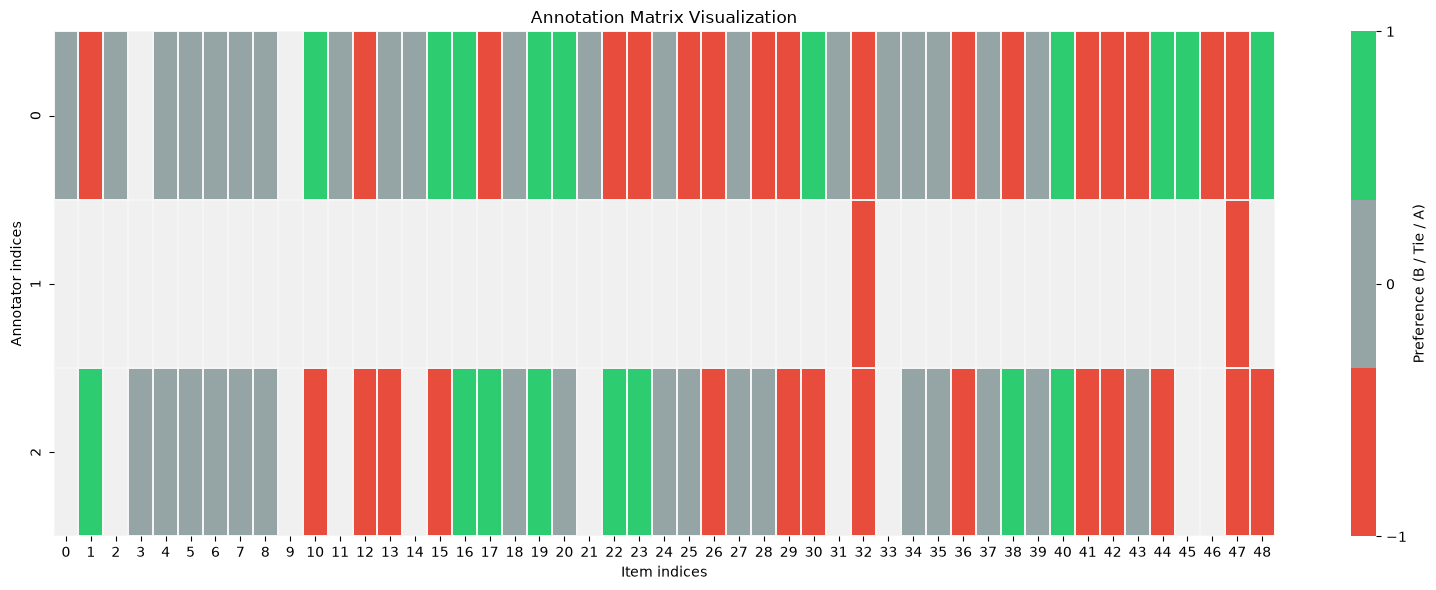

In [7]:
def visualize_matrix(matrix: np.ndarray, cmap: sns.palettes._ColorPalette, ticks: list[int], ticks_label: str, title: str, xlabel: str, ylabel: str) -> None:
    plt.figure(figsize=(16, 6))
    
    ax = sns.heatmap(
        matrix,
        cmap=cmap,
        cbar_kws={'ticks': ticks, 'label': ticks_label},
        linewidths=0.05,
        linecolor='whitesmoke'
    )
    
    ax.set_facecolor('#f0f0f0')
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    plt.tight_layout()
    plt.show()

visualize_matrix(matrix=load_data_matrix(), cmap = sns.color_palette(["#e74c3c", "#95a5a6", "#2ecc71"]), ticks=[-1, 0, 1], ticks_label='Preference (B / Tie / A)', title='Annotation Matrix Visualization', xlabel='Item indices', ylabel='Annotator indices')

When we look at agreement between expert annotators, it appears there is a high level of disagreement among them, below even chance (Krippendorff's $\alpha \approx -0.057$).

This suggests that the task may be inherently subjective (which it likely is) or that the guidelines provided to the annotators were perhaps not clear enough.

Computing Krippendorff's $\alpha$ on finer-grained categories may yield more precise information on that regard.

## Rating-wise

Bootstrapping:  33%|███▎      | 6633/20000 [00:00<00:01, 7383.34it/s]/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 7370.75it/s]


------------------------------------------------------------
                    Used Metric: ordinal                    
                 True Observed Alpha: 0.299                 
    Mean of Bootstrap: 0.202 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.556, 0.764]         
------------------------------------------------------------


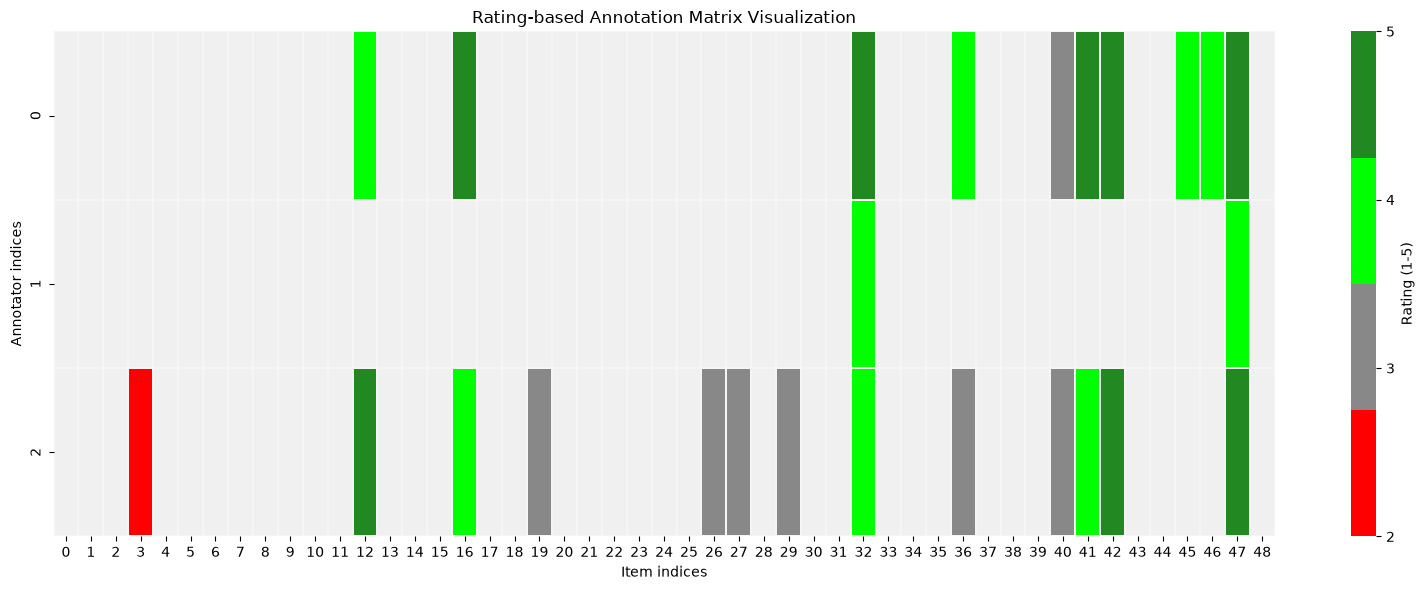

In [8]:
def load_matrix_ratings(input_path: str = INPUT_DATA_PATH) -> ndarray[tuple[int, int], dtype[Any]]:
    """
    Load annotation matrix from the gold JSON dataset, where each row corresponds to an annotator and each column corresponds to an annotated item. The matrix contains the numeric representation of the ratings (1-5), and fills missing annotations with `NaN` values. Only items with a consensus among all annotators (exactly 1 unique model chosen by all) are included in the matrix. The output matrix can be used to compute Krippendorff's alpha.
    """
    data = get_data(input_path)
    annotators = get_annotators(input_path)
    annotator_to_idx = {annotator: idx for idx, annotator in enumerate(annotators)}
    
    # Matrix filled with NaN values by default
    out_matrix = np.full((len(annotators), len(data)), np.nan)
    
    for i, item in enumerate(data):
        
        # Get all preferred models for this conversation
        preferred_models = set(
            ann.get("preferred_model")
            for ann in item
            if ann.get("preferred_model") is not None
        )
        
        # If there isn't an absolute consensus among all annotators (exactly 1 unique model chosen by all), we ignore this item and move on to the next one
        if len(preferred_models) != 1:
            continue
        
        for annotation in item:
            annotator_id = annotation.get("annotator_id")
            label: Literal[0, 1, 2, 3, 4, 5] = annotation.get("rating", 0)
            
            if annotator_id is not None and annotator_id in annotator_to_idx and label != 0: # 0 means no label provided
                out_matrix[annotator_to_idx[annotator_id], i] = label
                
    return out_matrix

# print("Krippendorff's alpha:", alpha(load_matrix_ratings(), value_domain=[1, 2, 3, 4, 5], level_of_measurement="ordinal"))
compute_alpha_with_ci(
    data_matrix=load_matrix_ratings(),
    level_of_measurement="ordinal",
    value_domain=[1, 2, 3, 4, 5],
    n_iterations=20000,
    p_value=0.05,
    seed=2026
)

visualize_matrix(matrix=load_matrix_ratings(), cmap = sns.color_palette(["#ff0000", "#888888", "#00ff00", "#228822"]), ticks=[1, 2, 3, 4, 5], ticks_label='Rating (1-5)', title='Rating-based Annotation Matrix Visualization', xlabel='Item indices', ylabel='Annotator indices')


## Label-wise

========================= complete =========================


Bootstrapping:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 9400.01it/s] 


------------------------------------------------------------
                    Used Metric: nominal                    
                 True Observed Alpha: 0.000                 
   Mean of Bootstrap: -0.036 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.167, 0.000]         
------------------------------------------------------------




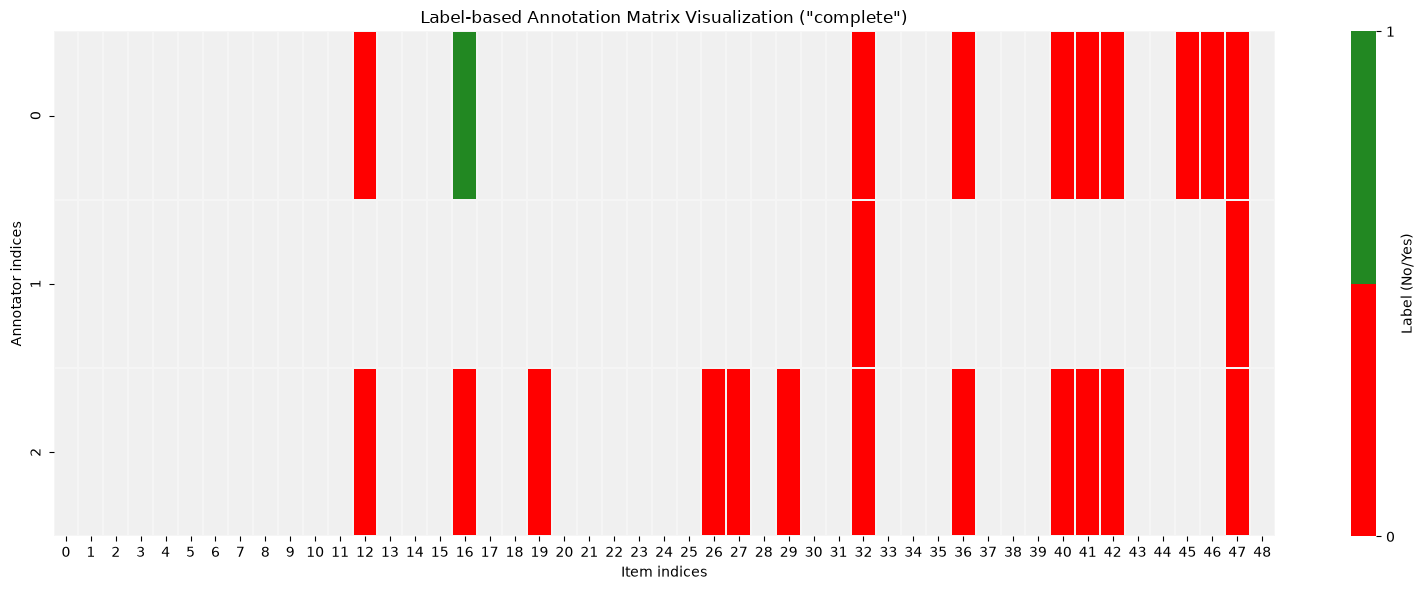

========================= correct ==========================


Bootstrapping:   0%|          | 0/20000 [00:00<?, ?it/s]/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 8428.45it/s]


------------------------------------------------------------
                    Used Metric: nominal                    
                 True Observed Alpha: 0.393                 
    Mean of Bootstrap: 0.312 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.231, 1.000]         
------------------------------------------------------------




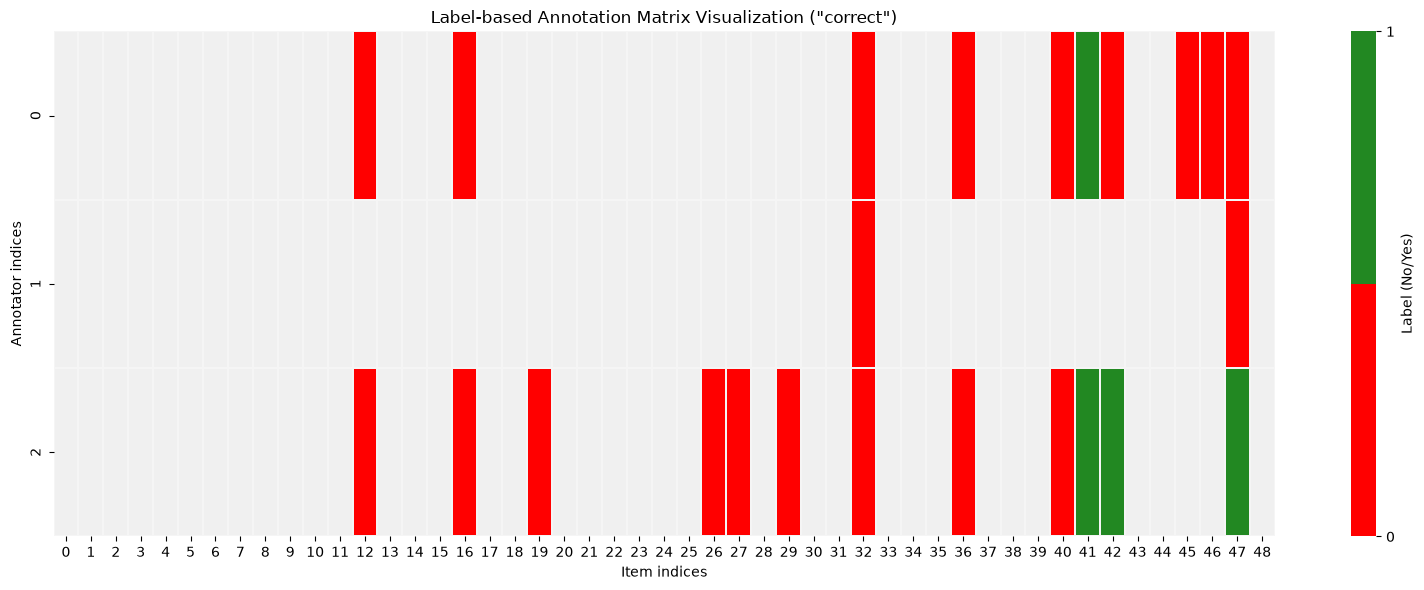

========================= relevant =========================


Bootstrapping:   0%|          | 0/20000 [00:00<?, ?it/s]/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 9194.83it/s]


------------------------------------------------------------
                    Used Metric: nominal                    
                 True Observed Alpha: 0.215                 
    Mean of Bootstrap: 0.144 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.375, 1.000]         
------------------------------------------------------------




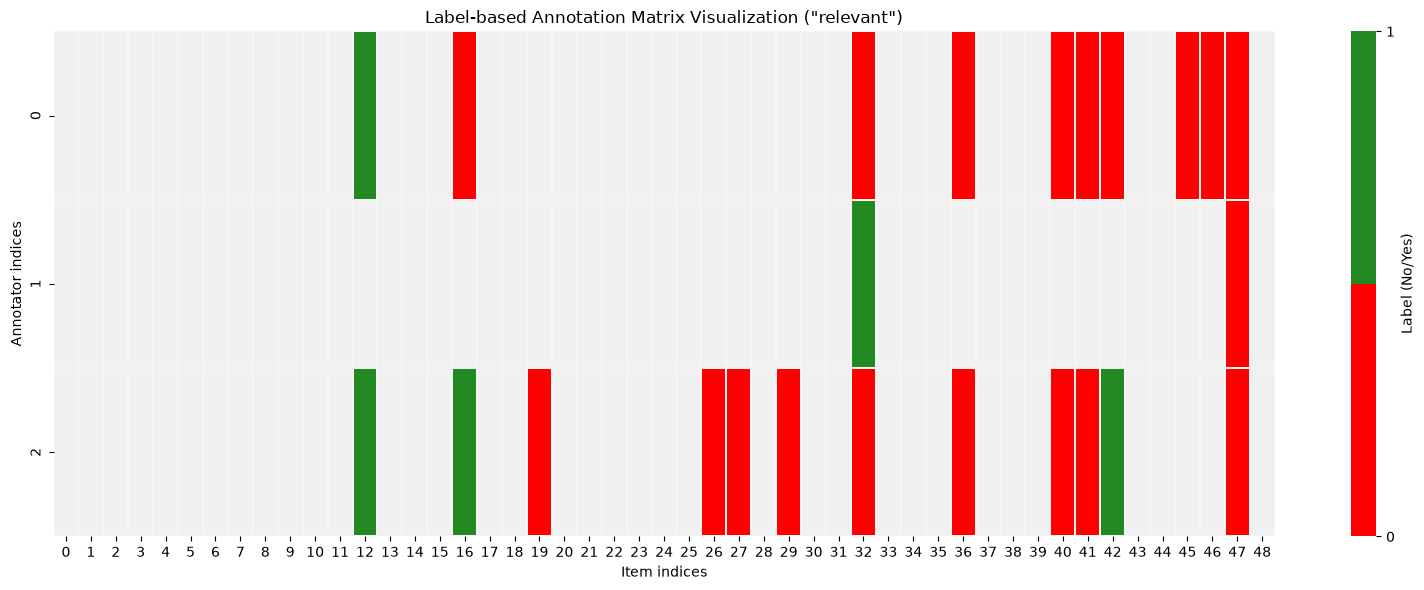

========================= concise ==========================


Bootstrapping:   0%|          | 0/20000 [00:00<?, ?it/s]/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 8485.29it/s]


------------------------------------------------------------
                    Used Metric: nominal                    
                True Observed Alpha: -0.214                 
   Mean of Bootstrap: -0.218 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.500, 0.000]         
------------------------------------------------------------




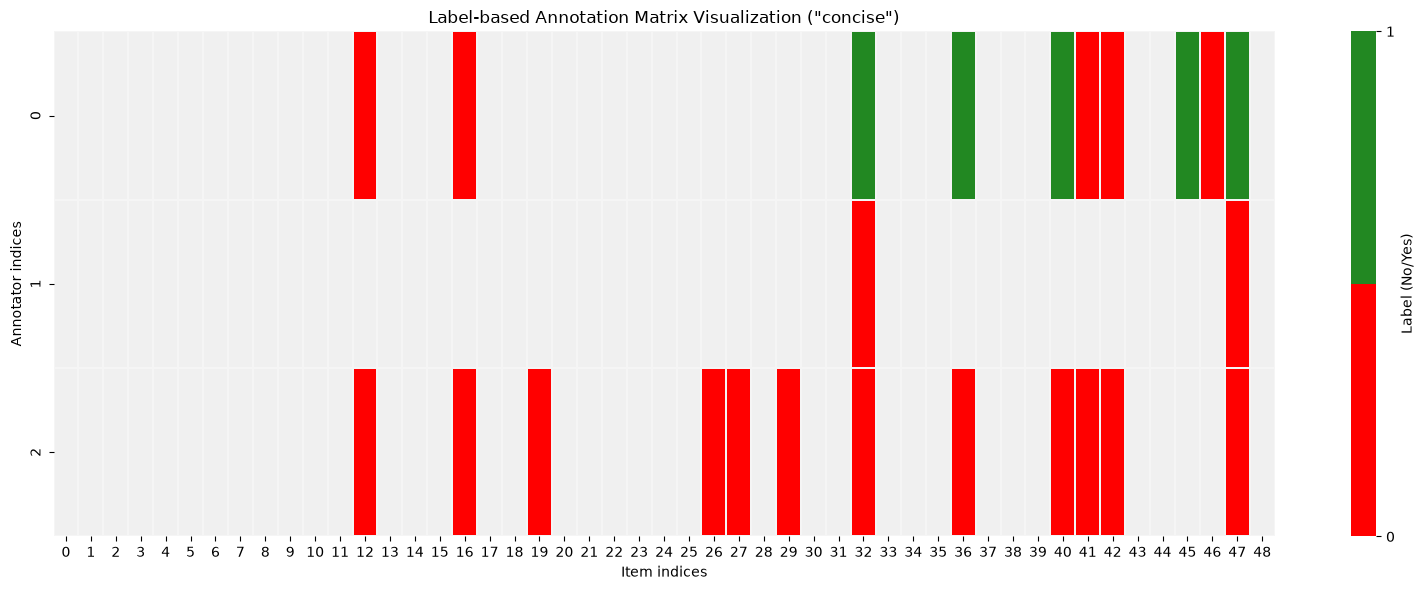

======================= scaffolding ========================


Bootstrapping:   0%|          | 0/20000 [00:00<?, ?it/s]/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 7998.70it/s]


------------------------------------------------------------
                    Used Metric: nominal                    
                True Observed Alpha: -0.046                 
   Mean of Bootstrap: -0.092 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.500, 0.312]         
------------------------------------------------------------




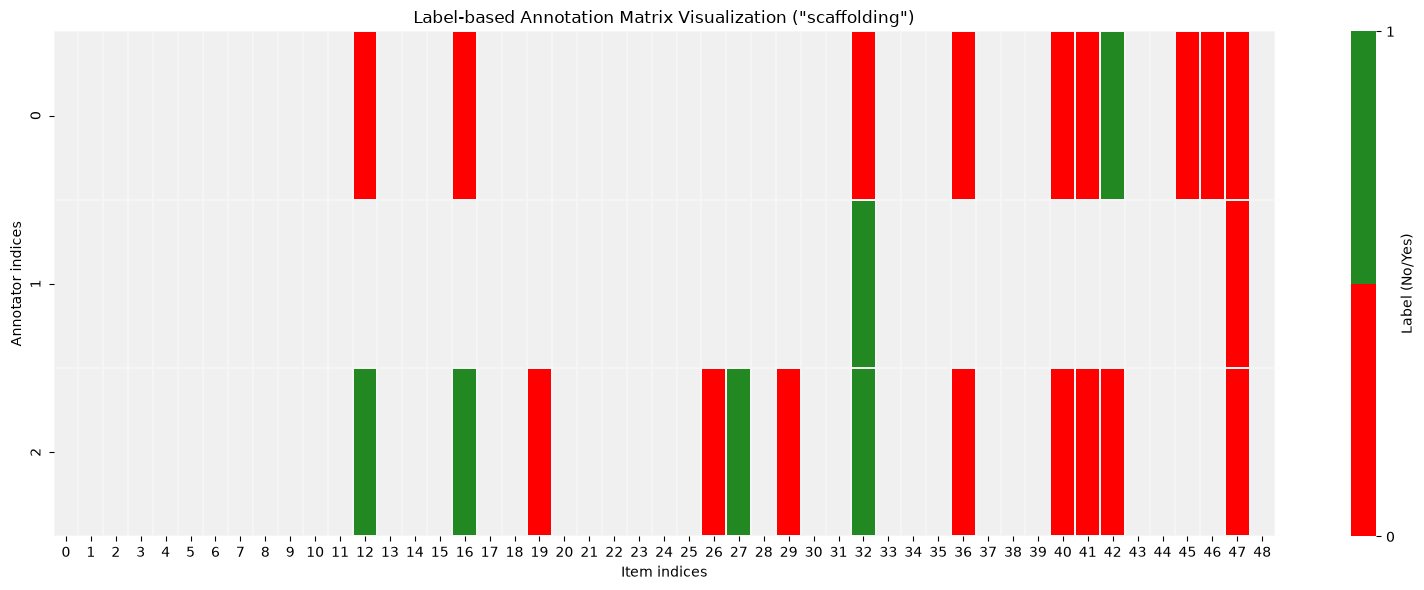

====================== understandable ======================


Bootstrapping:   0%|          | 0/20000 [00:00<?, ?it/s]/home/emile/Documents/Stage/Evaluation/.venv/lib/python3.11/site-packages/krippendorff/krippendorff.py:408: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (o * d).sum() / (e * d).sum()
Bootstrapping: 100%|██████████| 20000/20000 [00:02<00:00, 9351.56it/s]


------------------------------------------------------------
                    Used Metric: nominal                    
                True Observed Alpha: -0.417                 
   Mean of Bootstrap: -0.419 (Used as a bias diagnostic)    
        Confidence Interval at 95%: [-0.714, -0.125]        
------------------------------------------------------------




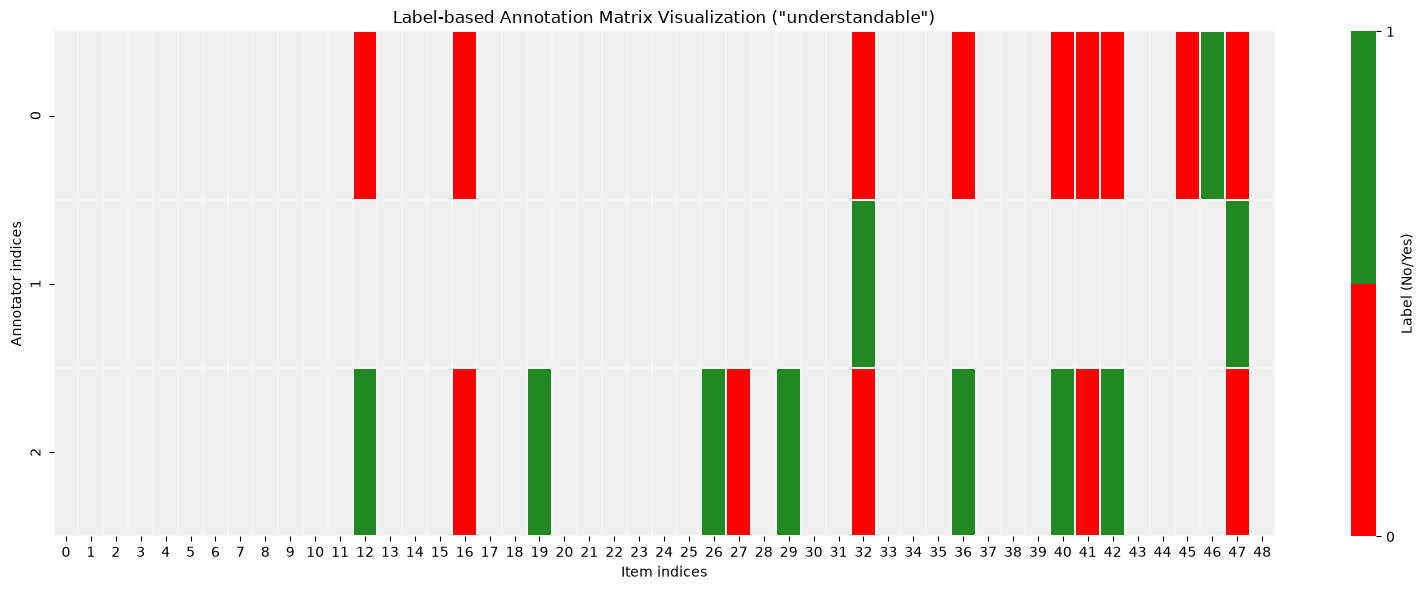

In [9]:
LABELS = ['complete', 'correct', 'relevant', 'concise', 'scaffolding', 'understandable']

def load_matrix_labels(target_label: Literal['complete', 'correct', 'relevant', 'concise', 'scaffolding', 'understandable'], input_path: str = INPUT_DATA_PATH, ) -> ndarray[tuple[int, int], dtype[Any]]:
    """
    Load annotation matrix from the gold JSON dataset, where each row corresponds to an annotator and each column corresponds to an annotated item. The matrix contains the boolean representation of a label (whether chosen or not), and fills missing annotations with `NaN` values. Only items with a consensus among all annotators (exactly 1 unique model chosen by all) are included in the matrix. The output matrix can be used to compute Krippendorff's alpha.
    """
    data = get_data(input_path)
    annotators = get_annotators(input_path)
    annotator_to_idx = {annotator: idx for idx, annotator in enumerate(annotators)}
    
    # Matrix filled with NaN values by default
    out_matrix = np.full((len(annotators), len(data)), np.nan)
    
    for i, item in enumerate(data):
        
        # Get all preferred models for this conversation
        preferred_models = set(
            ann.get("preferred_model")
            for ann in item
            if ann.get("preferred_model") is not None
        )
        
        # If there isn't an absolute consensus among all annotators (exactly 1 unique model chosen by all), we ignore this item and move on to the next one
        if len(preferred_models) != 1:
            continue
            
        for annotation in item:
            annotator_id = annotation.get("annotator_id")
            label_value = annotation.get(target_label)
            
            if annotator_id is not None and label_value is not None and any([annotation.get(label, False) for label in LABELS]): # We only keep annotations that have at least one label chosen (True) among the six labels => otherwise we assume that the annotator didn't provide any label for this item
                # Boolean values (False/True) are converted to 0 or 1
                out_matrix[annotator_to_idx[annotator_id], i] = int(label_value)
                
    return out_matrix

for label in LABELS:
    print(f" {label} ".center(60, '='))
    try:
        compute_alpha_with_ci(
            data_matrix=load_matrix_labels(target_label=label),
            level_of_measurement="nominal",
            value_domain=[0, 1],
            n_iterations=20000,
            p_value=0.05,
            seed=2026
        )
    except ValueError as e:
        print(f"Could not compute alpha for label '{label}': {e}")
    print('\n')

    visualize_matrix(matrix=load_matrix_labels(target_label=label), cmap = sns.color_palette(["#ff0000", "#228822"]), ticks=[0, 1], ticks_label='Label (No/Yes)', title=f'Label-based Annotation Matrix Visualization ("{label}")', xlabel='Item indices', ylabel='Annotator indices')


# Bradley-Terry-Davidson model

In [10]:
from scipy.optimize import minimize

In [71]:
def get_annotations_list(input_data_path: str = INPUT_DATA_PATH) -> list[tuple[str, str, str]]:
    """Extract annotation data from a JSON file and returns a formatted list of tuples (model_a, model_b, choice) for each annotation, which can be used to compute the Bradley-Terry-Davidson (BTD) model."""
    with open(input_data_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    out = []
    
    for item in data:
        model_a = item.get("model_a_name", "")
        model_b = item.get("model_b_name", "")
        
        for annotation in item.get("teacher_annotation_data", []):
            choice = annotation.get("preferred_model", "")
            if choice in ['a', 'b', 'both_equal']:
                out.append((model_a, model_b, choice))
            else:
                raise ValueError(f"Invalid choice '{choice}' for models '{model_a}' and '{model_b}'. Expected 'a', 'b', or 'both_equal'.")
    
    return out

def compute_btd_from_annotations(annotations_list):
    """
    Computes latent ability scores and the tie parameter using the 
    exact Bradley-Terry-Davidson (BTD) model via Maximum Likelihood Estimation (MLE).
    
    Args:
        annotations_list: List of tuples/lists (model_a, model_b, choice)
                          where choice indicates 'a', 'b', or 'both_equal' (tie).
                          
    Returns:
        results: Dictionary mapping each model name to its BTD latent score and rank.
        final_nu: The estimated Davidson tie parameter (nu > 0).
    """
    
    # -- Map models to sequential integer indices (alphabetically sorted)
    unique_models = sorted(list(set([m for row in annotations_list for m in row[:2]])))
    n_models = len(unique_models)
    
    model_to_idx = {model: idx for idx, model in enumerate(unique_models)}
    idx_to_model = {idx: model for model, idx in model_to_idx.items()}
    
    # -- Build aggregate Wins (W) and Ties (T) matrices
    wins = np.zeros((n_models, n_models), dtype=int)
    ties = np.zeros((n_models, n_models), dtype=int)
    
    for model_a, model_b, choice in annotations_list:
        idx_a = model_to_idx[model_a]
        idx_b = model_to_idx[model_b]
        
        choice_str = str(choice).strip().lower()
        
        # Accumulate wins directionally
        if choice_str == 'a':
            wins[idx_a, idx_b] += 1
        elif choice_str == 'b':
            wins[idx_b, idx_a] += 1
        # Accumulate ties symmetrically
        elif choice_str == 'both_equal':
            ties[idx_a, idx_b] += 1
            ties[idx_b, idx_a] += 1
        else:
            raise ValueError(f"Invalid choice '{choice}' for models '{model_a}' and '{model_b}'. Expected 'a', 'b', or 'both_equal'.")

    # -- Define the Davidson Negative Log-Likelihood objective function
    def btd_nll(params):
        # params contains: [theta_0, theta_1, ..., theta_{N-2}, nu]
        # We fix the last model's theta to 0.0 for statistical identifiability
        theta = np.append(params[:-1], 0.0)
        nu = params[-1]
        
        # The tie parameter nu must remain strictly positive
        if nu <= 0:
            return np.inf

        nll = 0.0
        
        # Iterate over all unique pairs (i < j)
        for i in range(n_models):
            for j in range(i + 1, n_models):
                w_ij = wins[i, j]
                w_ji = wins[j, i]
                t_ij = ties[i, j] # Symmetrically stored
                
                # Skip unobserved pairs
                if w_ij == 0 and w_ji == 0 and t_ij == 0:
                    continue

                # Exponentiate log-strengths for numerical stability
                exp_i = np.exp(theta[i])
                exp_j = np.exp(theta[j])
                
                # Davidson's joint denominator incorporating the tie parameter nu
                denom = exp_i + exp_j + nu * np.sqrt(exp_i * exp_j)
                
                if denom <= 0:
                    return np.inf

                # Compute log-probabilities for each outcome
                log_p_ij = np.log(exp_i / denom)
                log_p_ji = np.log(exp_j / denom)
                log_p_tie = np.log((nu * np.sqrt(exp_i * exp_j)) / denom)

                # Accumulate the Negative Log-Likelihood (weighted by observed frequencies)
                nll -= (w_ij * log_p_ij + w_ji * log_p_ji + t_ij * log_p_tie)
                
        return nll

    # -- Optimization via Bounded Maximum Likelihood estimation
    # Initial guesses: all latent scores set to 0.0, nu set to 1.0 (neutral baseline)
    initial_params = np.zeros(n_models)
    initial_params[-1] = 1.0
    
    # Bounds: latent scores can be unconstrained, nu must be > 0 (e.g., 1e-5)
    bounds = [(None, None)] * (n_models - 1) + [(1e-5, None)]

    # Minimize Negative Log-Likelihood using L-BFGS-B optimization algorithm
    with np.errstate(over='ignore', divide='ignore', invalid='ignore'): # Silently ignore cases when one models wins 100% of the time, leading to division by zero
        result = minimize(btd_nll, initial_params, method='L-BFGS-B', bounds=bounds)

    if not result.success:
        raise RuntimeError(f"BTD optimization failed to converge: {result.message}")

    # -- Post-processing
    final_theta = np.append(result.x[:-1], 0.0)
    
    # Center scores so their mean equals 0.0 for interpretation
    final_theta = final_theta - np.mean(final_theta) 
    final_nu = result.x[-1]

    # Sort models by descending latent score to build the final ranking structure
    sorted_indices = np.argsort(final_theta)[::-1]
    results = {
        idx_to_model[idx]: {
            "score": float(final_theta[idx]),
            "rank": rank + 1,
            "wins/draws/losses": (int(np.sum(wins[idx, :])), int(np.sum(wins[:, idx])), int(np.sum(ties[idx, :])))
        }
        for rank, idx in enumerate(sorted_indices)
    }
    
    return results, final_nu


def compute_btd_with_ci(annotations_list: list, n_iterations: int = 1000, p_value: float = 0.05, seed: int = 2026) -> tuple[dict[Any, dict[str, Any]], Any]:
    """
    Compute the BTD model using bootstrapping to estimate confidence intervals.
    """
    rng = np.random.default_rng(seed)
    
    true_results, true_nu = compute_btd_from_annotations(annotations_list)
    
    models = list(true_results.keys())
    bootstrapped_scores = {model: [] for model in models}
    n_samples = len(annotations_list)
    
    for _ in tqdm(range(n_iterations), desc="Bootstrapping BTD"):
        # Draw a sample of the annotations with replacement
        indices = rng.choice(n_samples, size=n_samples, replace=True)
        resampled_annotations = [annotations_list[i] for i in indices]
        
        try:
            # Recompute the BTD model on the resampled annotations
            res, _ = compute_btd_from_annotations(resampled_annotations)
            
            for model in models:
                if model in res:
                    bootstrapped_scores[model].append(res[model]["score"])
                else:
                    bootstrapped_scores[model].append(np.nan)
                    
        except RuntimeError:
            continue

    lower_percentile = (p_value / 2.0) * 100
    upper_percentile = (1.0 - p_value / 2.0) * 100
    
    for model in models:
        scores_array = np.array(bootstrapped_scores[model])
        
        if len(scores_array) == 0:
            true_results[model]["ci_lower"] = np.nan
            true_results[model]["ci_upper"] = np.nan
            continue
            
        ci_lower = np.nanpercentile(scores_array, lower_percentile)
        ci_upper = np.nanpercentile(scores_array, upper_percentile)
        
        true_results[model]["ci_lower"] = float(ci_lower)
        true_results[model]["ci_upper"] = float(ci_upper)
        true_results[model]["bootstrapped_scores_array"] = scores_array.tolist()
        
    return true_results, true_nu

In [12]:
btd_scores, nu = compute_btd_with_ci(get_annotations_list(INPUT_DATA_PATH))
print(btd_scores)

Bootstrapping BTD: 100%|██████████| 1000/1000 [00:27<00:00, 36.28it/s]

{'openai/gpt-5.4-mini': {'score': 1.0688865323787284, 'rank': 1, 'wins/draws/losses': (9, 2, 12), 'ci_lower': 0.08380562038898332, 'ci_upper': 2.3557586917539433, 'bootstrapped_scores_array': [0.8827734343743033, 1.4898740888607893, 0.568066684553216, 0.4713689723398917, 0.8637109844936457, 1.8914986696509424, 1.363638188248676, -2.0875413103785485, 1.0947720409356199, 0.9272562843389075, 1.774721980940467, 1.280905583753347, 1.4290161290352086, 0.4967177964854598, 0.5122842413832691, 0.9821587181812923, 1.2605649769031086, 1.4088528254299484, 1.379459461398087, 1.3328456365313945, 0.3894998608279521, 1.9822804486390944, 0.5141423367070279, 1.2497622548734109, 0.9439625209337097, 2.0420864791503317, 0.6304005276200826, 1.729119378844355, 0.41637300108157527, 1.151568198924378, 0.911688002253188, -0.07352113098448256, 0.8728006390976452, 1.9681946775374004, 0.9488549091124648, 0.6996255724201027, 0.621002784361055, 0.3154504320815212, 1.2132096361244549, 2.7214852098996474, 1.8753402494

In [13]:
def visualize_btd_scores(scores_dict: dict):
    plt.figure(figsize=(12, 6))
    models = list(scores_dict.keys())
    scores = [scores_dict[model]["score"] for model in models]
    ci_lowers = [scores_dict[model]["ci_lower"] for model in models]
    ci_uppers = [scores_dict[model]["ci_upper"] for model in models]
    
    plt.bar(models, scores, yerr=[np.array(scores) - np.array(ci_lowers), np.array(ci_uppers) - np.array(scores)], capsize=5, color='skyblue', edgecolor='black')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title("Bradley-Terry-Davidson Scores per Model")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

N_ITERATIONS = 1000

def compute_significance_matrix(scores: dict, n_iterations: int = N_ITERATIONS) -> pd.DataFrame:
    """
    Compute a significance matrix for pairwise comparisons of models based on their bootstrapped scores. The matrix contains empirical p-values and significance stars for each pair of models, indicating whether one model is significantly better than another.
    """
    models = list(scores.keys())
    # Ordering models by their median bootstrapped score for better visualization
    models.sort(key=lambda m: np.median(scores[m]["bootstrapped_scores_array"]), reverse=True)
    
    p_value_matrix = pd.DataFrame(index=models, columns=models, dtype=object)
    stars_matrix = p_value_matrix.copy()
    
    for i, model_a in enumerate(models):
        scores_a = np.array(scores[model_a]["bootstrapped_scores_array"])
        
        for j, model_b in enumerate(models):
            if i == j:
                p_value_matrix.loc[model_a, model_b] = "-"
                stars_matrix.loc[model_a, model_b] = "-"
                continue
                
            scores_b = np.array(scores[model_b]["bootstrapped_scores_array"])
            
            # Empirical p-value: proportion of bootstrap samples where Model B's score >= Model A's score,
            # when A is assumed to be better according to the ranking
            p_value = np.sum(scores_b >= scores_a) / n_iterations
            
            # We keep only the valid scores (where neither is NaN, i.e. both models have scores for a given iteration) to ensure accurate p-value computation
            valid_mask = ~np.isnan(scores_a) & ~np.isnan(scores_b)
            valid_a = scores_a[valid_mask]
            valid_b = scores_b[valid_mask]
            
            if len(valid_a) == 0:
                p_value = np.nan
            else:
                p_value = np.sum(valid_b >= valid_a) / len(valid_a)
            
            if p_value <= 0.001:
                stars = "***"
            elif p_value <= 0.01:
                stars = "**"
            elif p_value <= 0.05:
                stars = "*"
            else:
                stars = ""
                
            p_value_matrix.loc[model_a, model_b] = f"{p_value:10.3e}"
            stars_matrix.loc[model_a, model_b] = stars

    return p_value_matrix, stars_matrix

In [14]:
def compute_win_probabilities(scores_dict: dict, nu: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    models = list(scores_dict.keys())
    models.sort(key=lambda m: scores_dict[m]["score"], reverse=True)
    
    n_models = len(models)
    
    pairwise_matrix = pd.DataFrame(index=models, columns=models, dtype=float)
    expected_win_rates = {}

    for i, model_a in enumerate(models):
        theta_a = scores_dict[model_a]["score"]
        sum_win_probs = 0.0
        
        for j, model_b in enumerate(models):
            if i == j:
                pairwise_matrix.loc[model_a, model_b] = np.nan
                continue
                
            theta_b = scores_dict[model_b]["score"]
            
            # Computing the Davidson denominator (which includes the tie risk)
            denom = np.exp(theta_a) + np.exp(theta_b) + nu * np.sqrt(np.exp(theta_a) * np.exp(theta_b))
            
            # Probability of A winning against B
            p_a_wins = np.exp(theta_a) / denom
            
            # A = lines, B = columns
            pairwise_matrix.loc[model_a, model_b] = p_a_wins
            sum_win_probs += p_a_wins
            
        # Computing the Expected Win Rate (Average of win probabilities against the rest of the pool)
        expected_win_rates[model_a] = sum_win_probs / (n_models - 1)
        
    ewr_df = pd.DataFrame.from_dict(
        expected_win_rates, 
        orient='index', 
        columns=['Expected Global Win Rate']
    ).sort_values(by='Expected Global Win Rate', ascending=False).map(lambda x: f"{x:.1%}" if pd.notnull(x) else "-")
    
    pairwise_matrix = pairwise_matrix.map(lambda x: f"{x:.1%}" if pd.notnull(x) else "-")
        
    return pairwise_matrix, ewr_df

pairwise_probs, global_ewr = compute_win_probabilities(btd_scores, nu)

In [15]:
global_ewr

,Expected Global Win Rate
openai/gpt-5.4-mini,46.2%
mistralai/mistral-medium-3,35.9%
deepseek/deepseek-v4-pro,33.2%
google/gemini-3.1-flash-lite-preview,32.7%
openai/gpt-5.4,32.6%
mistralai/mistral-large-2512,24.8%
google/gemini-3-flash-preview,17.0%
deepseek/deepseek-v4-flash,12.7%


In [16]:
print("Likelihood of each model per line winning against all other models per column:")
pairwise_probs

Likelihood of each model per line winning against all other models per column:


,openai/gpt-5.4-mini,mistralai/mistral-medium-3,deepseek/deepseek-v4-pro,google/gemini-3.1-flash-lite-preview,openai/gpt-5.4,mistralai/mistral-large-2512,google/gemini-3-flash-preview,deepseek/deepseek-v4-flash
openai/gpt-5.4-mini,-,36.8%,39.4%,39.9%,40.0%,47.9%,56.9%,62.4%
mistralai/mistral-medium-3,20.0%,-,30.2%,30.7%,30.8%,38.4%,47.6%,53.6%
deepseek/deepseek-v4-pro,18.1%,25.6%,-,28.3%,28.4%,35.9%,45.0%,51.0%
google/gemini-3.1-flash-lite-preview,17.8%,25.1%,27.4%,-,27.9%,35.4%,44.5%,50.5%
openai/gpt-5.4,17.7%,25.1%,27.3%,27.8%,-,35.3%,44.5%,50.5%
mistralai/mistral-large-2512,12.7%,18.8%,20.7%,21.1%,21.2%,-,36.5%,42.5%
google/gemini-3-flash-preview,8.4%,12.9%,14.4%,14.7%,14.8%,20.2%,-,33.5%
deepseek/deepseek-v4-flash,6.2%,9.8%,11.1%,11.4%,11.4%,16.0%,22.7%,-


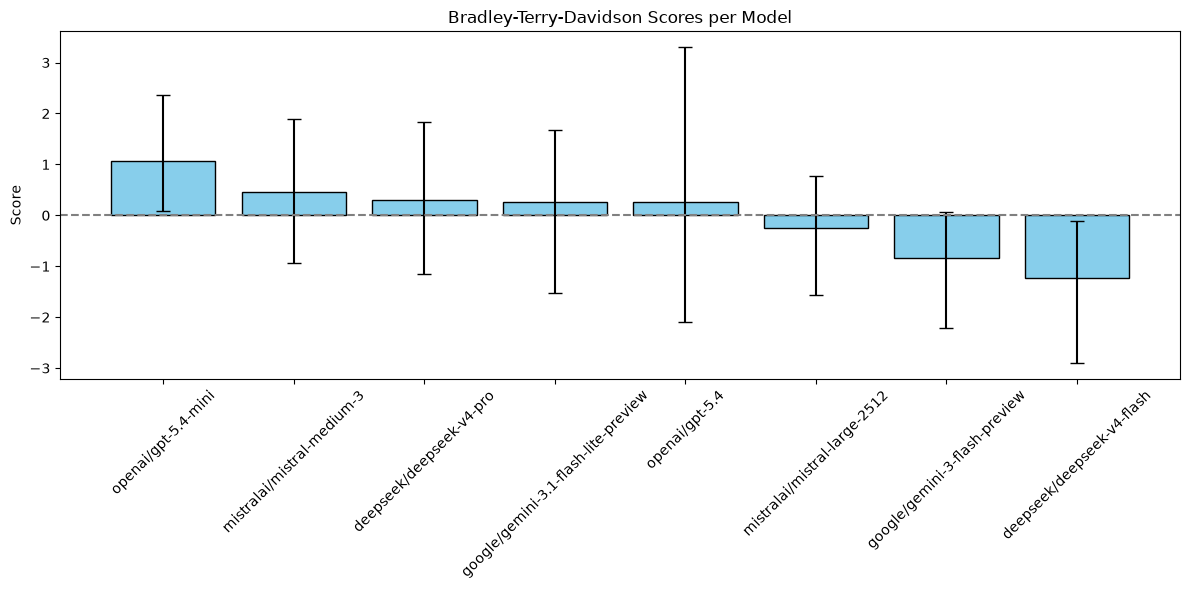

In [17]:
visualize_btd_scores(btd_scores)
p_value_matrix, stars_matrix = compute_significance_matrix(btd_scores, n_iterations=N_ITERATIONS)

In [18]:
p_value_matrix

,openai/gpt-5.4-mini,mistralai/mistral-medium-3,openai/gpt-5.4,deepseek/deepseek-v4-pro,google/gemini-3.1-flash-lite-preview,mistralai/mistral-large-2512,google/gemini-3-flash-preview,deepseek/deepseek-v4-flash
openai/gpt-5.4-mini,-,1.950e-01,2.680e-01,1.390e-01,1.970e-01,3.700e-02,2.000e-03,3.000e-03
mistralai/mistral-medium-3,8.050e-01,-,4.660e-01,3.920e-01,4.110e-01,2.110e-01,6.400e-02,4.400e-02
openai/gpt-5.4,7.320e-01,5.340e-01,-,5.000e-01,4.810e-01,3.120e-01,1.840e-01,1.220e-01
deepseek/deepseek-v4-pro,8.610e-01,6.080e-01,5.000e-01,-,5.170e-01,2.720e-01,9.600e-02,6.000e-02
google/gemini-3.1-flash-lite-preview,8.030e-01,5.890e-01,5.190e-01,4.830e-01,-,1.900e-01,1.060e-01,6.100e-02
mistralai/mistral-large-2512,9.630e-01,7.890e-01,6.880e-01,7.280e-01,8.100e-01,-,1.950e-01,1.160e-01
google/gemini-3-flash-preview,9.980e-01,9.360e-01,8.160e-01,9.040e-01,8.940e-01,8.050e-01,-,2.870e-01
deepseek/deepseek-v4-flash,9.970e-01,9.560e-01,8.780e-01,9.400e-01,9.390e-01,8.840e-01,7.130e-01,-


In [19]:
stars_matrix

,openai/gpt-5.4-mini,mistralai/mistral-medium-3,openai/gpt-5.4,deepseek/deepseek-v4-pro,google/gemini-3.1-flash-lite-preview,mistralai/mistral-large-2512,google/gemini-3-flash-preview,deepseek/deepseek-v4-flash
openai/gpt-5.4-mini,-,,,,,*,**,**
mistralai/mistral-medium-3,,-,,,,,,*
openai/gpt-5.4,,,-,,,,,
deepseek/deepseek-v4-pro,,,,-,,,,
google/gemini-3.1-flash-lite-preview,,,,,-,,,
mistralai/mistral-large-2512,,,,,,-,,
google/gemini-3-flash-preview,,,,,,,-,
deepseek/deepseek-v4-flash,,,,,,,,-


# Agreement between student and professor scores (at the role level)

## Raw agreement

In [20]:
from collections import defaultdict

def get_full_data(input_data_path: str = INPUT_DATA_PATH) -> list[dict[str, Any]]:
    with open(input_data_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        return data

annotations_list = []

for item in get_full_data(INPUT_DATA_PATH):
    id = item.get("reaction_id")
    student_annotations = defaultdict()

    student_annotations.update({"preferred_model": item.get("preferred_model")})
    student_annotations.update({"rating": item.get("rating")})
    student_annotations.update({"comment": item.get("comment")})
    
    labels = item.get("labels", {})
    student_annotations.update(**labels)

    model_a = item.get("model_a_name", "")
    model_b = item.get("model_b_name", "")
    
    teacher_annotations: list[dict] = item.get("teacher_annotation_data", [])
    
    for teacher_annotation in teacher_annotations:
        preferred_model = teacher_annotation.get("preferred_model", "")
        teacher_annotation.update({"preferred_model": model_a if preferred_model == 'a' else model_b if preferred_model == 'b' else None})
        del teacher_annotation["id"]
        del teacher_annotation["timestamp"]
    
    annotations_list.append({
        "id": id,
        "student_annotation": student_annotations,
        "teacher_annotation": teacher_annotations
    })

print(json.dumps(annotations_list, indent=4, ensure_ascii=False))

[
    {
        "id": 528,
        "student_annotation": {
            "preferred_model": "deepseek/deepseek-v4-pro",
            "rating": 0,
            "comment": null,
            "complete": false,
            "correct": false,
            "relevant": false,
            "concise": false,
            "scaffolding": false,
            "understandable": false
        },
        "teacher_annotation": [
            {
                "annotator_id": "63e199e3-c337-4159-b0ba-fd8e9ab38b9e",
                "preferred_model": null,
                "rating": 0,
                "comment": null,
                "complete": false,
                "correct": false,
                "relevant": false,
                "concise": false,
                "scaffolding": false,
                "understandable": false
            }
        ]
    },
    {
        "id": 522,
        "student_annotation": {
            "preferred_model": "openai/gpt-5.4",
            "rating": 5,
            "comment": nul

============= Agreements for label 'complete': =============
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 10/15 (66.67%)    
    ccb30d89-40f2-4fbf-a6d8-e4857692d814: 7/13 (53.85%)     


============= Agreements for label 'correct': ==============
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 13/15 (86.67%)    
    ccb30d89-40f2-4fbf-a6d8-e4857692d814: 10/13 (76.92%)    


============= Agreements for label 'relevant': =============
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 10/15 (66.67%)    
    ccb30d89-40f2-4fbf-a6d8-e4857692d814: 7/13 (53.85%)     


============= Agreements for label 'concise': ==============
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 9/15 (60.00%)     
    ccb30d89-40f2-4fbf-a6d8-e4857692d814: 10/13 (76.92%)    


=========== Agreements for label 'scaffolding': ============
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 10/15 (66.67%)    
    ccb30d89-40f2-4fbf-a6d8-e4857692d814: 7/13 (53.85%)     


========== Agreements for label 'understandable': ==========
    63e199e3-c

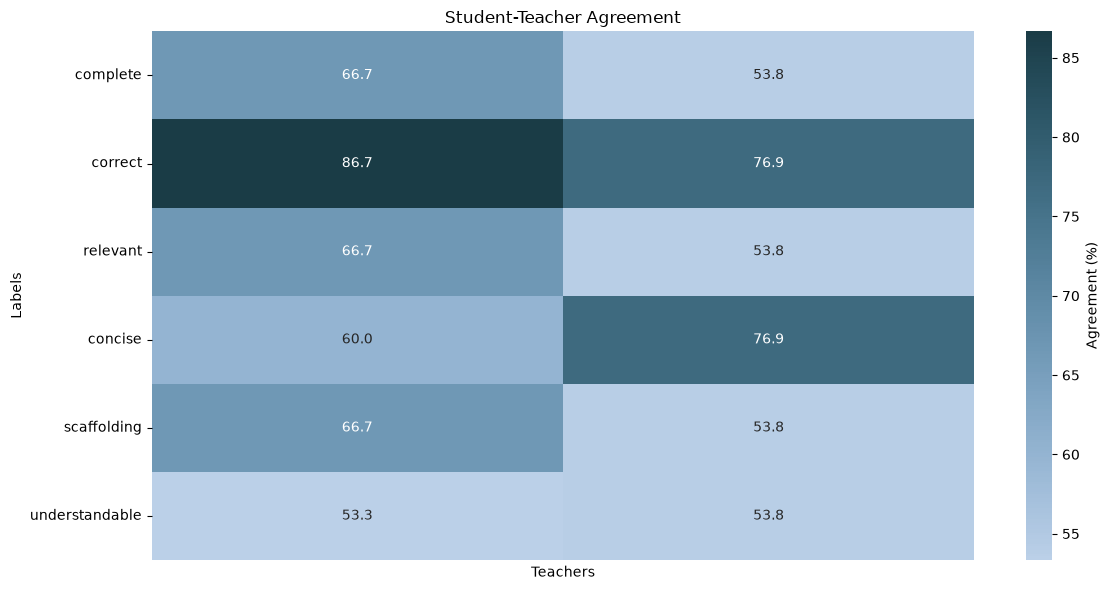

In [21]:
def compute_student_teacher_agreement_per_label(label: Literal['complete', 'correct', 'relevant', 'concise', 'scaffolding', 'understandable'], filtered_out_annotators: list[str] = ["96278cf1-da97-430d-a30a-ef6fad1f6279"], input_data_path: str = INPUT_DATA_PATH) -> dict[str, tuple[int, int]]:
    
    out = defaultdict(lambda: (0, 0))
    
    for annotator in [ ann for ann in get_annotators(input_data_path) if ann not in filtered_out_annotators ]:

        observed_item_count = 0
        agreement_count = 0
        
        for item in annotations_list:
            
            teacher_annotation = next(
                (ann for ann in item.get("teacher_annotation", []) if ann.get("annotator_id") == annotator), 
                None
            )
            
            if teacher_annotation is None: # If the teacher annotation is missing for this item, we skip it
                continue
            
            student_annotation = item.get("student_annotation", {})
            
            student_preferred_model = student_annotation.get("preferred_model")
            teacher_preferred_model = teacher_annotation.get("preferred_model")
            
            if student_preferred_model == teacher_preferred_model:
                observed_item_count += 1
                
                student_annotation = item.get("student_annotation", {})
                student_label = student_annotation.get(label)
                teacher_label = teacher_annotation.get(label)
                
                
                if student_label is not None and teacher_label is not None and student_label == teacher_label:
                    agreement_count += 1
        
        out[annotator] = agreement_count, observed_item_count
    
    return out

def visualize_heatmap_global_student_teacher_agreement(filtered_out_annotators: list[str] = ["96278cf1-da97-430d-a30a-ef6fad1f6279"]) -> None:
    
    annotators = [annotator for annotator in get_annotators() if annotator not in filtered_out_annotators]
    
    data = {}
    
    for label in LABELS:
        agreement_results = compute_student_teacher_agreement_per_label(label, filtered_out_annotators)
        data[label] = {}
        
        for annotator, (agreement_count, observed_item_count) in agreement_results.items():
            data[label][annotator] = (agreement_count, observed_item_count)
    
    plt.figure(figsize=(12, 6))
    heatmap_data = np.zeros((len(LABELS), len(annotators)))
    for i, label in enumerate(LABELS):
        for j, annotator in enumerate(annotators):
            if annotator in data[label]:
                agreement_count, observed_item_count = data[label][annotator]
                heatmap_data[i, j] = agreement_count / observed_item_count * 100 if observed_item_count > 0 else 0.0

    sns.heatmap(heatmap_data, annot=True, fmt='.1f', xticklabels=False, yticklabels=LABELS, cmap=sns.color_palette("ch:s=-.5,r=.1,d=.2,l=.8", as_cmap=True), cbar_kws={'label': 'Agreement (%)'})
    plt.title("Student-Teacher Agreement")
    plt.xlabel("Teachers")
    plt.ylabel("Labels")
    plt.tight_layout()
    plt.show()

def compute_global_student_teacher_agreement(filtered_out_annotators: list[str] = ["96278cf1-da97-430d-a30a-ef6fad1f6279"], input_data_path: str = INPUT_DATA_PATH) -> dict[str, dict[str, float]]:
    out = {}
    
    for label in LABELS:
        agreement_results = compute_student_teacher_agreement_per_label(label, filtered_out_annotators, input_data_path)
        print(f" Agreements for label '{label}': ".center(60, '='))
        for annotator, (agreement_count, observed_item_count) in agreement_results.items():
            percentage = agreement_count / observed_item_count * 100 if observed_item_count > 0 else 0.0
            print(f"{annotator}: {agreement_count}/{observed_item_count} ({percentage:.2f}%)".center(60))
            
            if annotator not in out:
                out[annotator] = [0, 0]
            out[annotator][0] += agreement_count
            out[annotator][1] += observed_item_count
        print('\n')
    
    print('='*60, '\n', " Global Student-Teacher Agreement: ".center(60, '='), '\n', '='*60)
    
    for annotator, (total_agreement, total_observed) in out.items():
        percentage = total_agreement / total_observed * 100 if total_observed > 0 else 0.0
        print(f"{annotator}: {total_agreement}/{total_observed} ({percentage:.2f}%)".center(60))
    
    return out

global_agreement_values = compute_global_student_teacher_agreement()
visualize_heatmap_global_student_teacher_agreement()

In [22]:
def compute_student_teacher_agreement_per_metric(metric: Literal['preferred_model', 'rating'] = "preferred_model", filtered_out_annotators: list[str] = ["96278cf1-da97-430d-a30a-ef6fad1f6279"], input_data_path: str = INPUT_DATA_PATH) -> dict[str, tuple[int, int]]:
    
    if metric not in ['rating', 'preferred_model']:
        raise ValueError(f"Invalid metric '{metric}'. Expected 'rating' or 'preferred_model'.")
    
    out = defaultdict(lambda: (0, 0))
    
    for annotator in [ ann for ann in get_annotators(input_data_path) if ann not in filtered_out_annotators ]:

        observed_item_count = 0
        agreement_count = 0
        
        for item in annotations_list:
            
            teacher_annotation = next(
                (ann for ann in item.get("teacher_annotation", []) if ann.get("annotator_id") == annotator), 
                None
            )
            
            if teacher_annotation is None: # If the teacher annotation is missing for this item, we skip it
                continue
                        
            student_annotation = item.get("student_annotation", {})
            
            student_preferred_model = student_annotation.get("preferred_model")
            teacher_preferred_model = teacher_annotation.get("preferred_model")
                
            if metric == "preferred_model":
                student_metric = student_preferred_model
                teacher_metric = teacher_preferred_model
                
                observed_item_count += 1
                
                if student_metric == teacher_metric:
                    agreement_count += 1
            
            else :# metric == "rating":
                student_metric = student_annotation.get("rating")
                teacher_metric = teacher_annotation.get("rating")
                
                if student_preferred_model == teacher_preferred_model:
                    observed_item_count += 1
                    if student_metric and teacher_metric and student_metric == teacher_metric:
                        agreement_count += 1
        
        out[annotator] = agreement_count, observed_item_count
        
    print('='*60, '\n', f" Student-Teacher Agreement ({metric}): ".center(60, '='), '\n', '='*60)
    
    for annotator, (total_agreement, total_observed) in out.items():
        percentage = total_agreement / total_observed * 100 if total_observed > 0 else 0.0
        print(f"{annotator}: {total_agreement}/{total_observed} ({percentage:.2f}%)".center(60))
    
    return out

In [23]:
preferred_model_agreement = compute_student_teacher_agreement_per_metric("preferred_model")
rating_agreement = compute_student_teacher_agreement_per_metric("rating")

 ======= Student-Teacher Agreement (preferred_model): ======= 
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 15/47 (31.91%)    
    ccb30d89-40f2-4fbf-a6d8-e4857692d814: 13/39 (33.33%)    
 =========== Student-Teacher Agreement (rating): ============ 
    63e199e3-c337-4159-b0ba-fd8e9ab38b9e: 4/15 (26.67%)     
     ccb30d89-40f2-4fbf-a6d8-e4857692d814: 1/13 (7.69%)     


## Chance-corrected agreement (Gwet's AC1)

In [67]:
from irrCAC.raw import CAC

def get_agreement_and_ac1_data(filtered_out_annotators: list[str] = ["96278cf1-da97-430d-a30a-ef6fad1f6279"]):
    annotators = [ann for ann in get_annotators() if ann not in filtered_out_annotators]
    
    data_matrix = {}
    
    for label in LABELS:
        data_matrix[label] = {}
        
        for annotator in annotators:
            student_votes = []
            teacher_votes = []
            
            for item in annotations_list:
                teacher_ann = next(
                    (ann for ann in item.get("teacher_annotation", []) if ann.get("annotator_id") == annotator),
                    None
                )
                
                if teacher_ann is None:
                    continue
                
                student_ann = item.get("student_annotation", {})
                
                student_pref = student_ann.get("preferred_model")
                teacher_pref = teacher_ann.get("preferred_model")
                
                if student_pref != teacher_pref:
                    continue # We only consider items where the student and teacher agreed on the preferred model for this item
                    
                student_label = student_ann.get(label)
                teacher_label = teacher_ann.get(label)
                
                if student_label is not None and teacher_label is not None:
                    # Explicit conversion to string to ensure compatibility with irrCAC
                    student_votes.append(str(student_label))
                    teacher_votes.append(str(teacher_label))
            
            n = len(student_votes)
            
            if n > 1: # At least two votes are needed to compute agreement and AC1
                # Raw agreement percentage
                s_array = np.array(student_votes)
                t_array = np.array(teacher_votes)
                raw_agreement = np.sum(s_array == t_array) / n * 100
                
                # AC1 score
                df_ratings = pd.DataFrame({
                    'Student': student_votes,
                    'Teacher': teacher_votes
                })
                
                cac = CAC(df_ratings)

                try:
                    ac1_results = cac.gwet()
                    
                    ac1_score = ac1_results['est']['coefficient_value']
                    p_value = ac1_results['est']['p_value']
                except Exception as e:
                    print(e)
                    ac1_score = 1.0 if raw_agreement == 100.0 else 0.0
                    p_value = np.nan
                
            else:
                raw_agreement = 0.0
                ac1_score = np.nan
                p_value = np.nan
                
            data_matrix[label][annotator] = {
                "raw_percent": raw_agreement,
                "ac1": ac1_score,
                "p_value": p_value
            }
            
    return data_matrix, annotators

def visualize_heatmap_ac1_and_agreement(data_matrix: dict, annotators: list[str], labels: list[str] = LABELS) -> None:
    """
    Show a heatmap of the AC1 scores, significance, and raw agreement percentages for each label and annotator.
    """
    # Initialising matrices (colours for AC1, text pour display)
    ac1_data = np.zeros((len(labels), len(annotators)))
    annot_data = np.empty((len(labels), len(annotators)), dtype=object)

    for i, label in enumerate(labels):
        for j, annotator in enumerate(annotators):
            stats = data_matrix[label].get(annotator, {})
            
            ac1 = stats.get("ac1", np.nan)
            raw_pct = stats.get("raw_percent", 0.0)
            p_val = stats.get("p_value", 1.0)
            
            # Colour matrix (we set to 0 if score calculation failed)
            ac1_data[i, j] = ac1 if not np.isnan(ac1) else 0.0
            
            # Significance stars
            stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            
            # Formatting text within the heatmap cell: AC1 score with 2 decimals, significance stars, and raw agreement percentage with 1 decimal
            if not np.isnan(ac1):
                annot_data[i, j] = f"{ac1:.3f} {'(' + stars + ')' if stars else ''}\n({raw_pct:.1f}%)"
            else:
                annot_data[i, j] = f"N/A\n({raw_pct:.1f}%)"

    # Cleaning of identifiers (to avoid long UUIDs from distorting the X-axis)
    clean_annotators = [f"Prof {k+1}\n({ann[:8]})" for k, ann in enumerate(annotators)]

    plt.figure(figsize=(10, 6))
    
    ax = sns.heatmap(
        ac1_data,
        annot=annot_data,
        fmt="",
        xticklabels=clean_annotators,
        yticklabels=labels,
        cmap=sns.color_palette("ch:s=-.5,r=.1,d=.2,l=.8", as_cmap=True),
        vmin=0.0, vmax=1.0,
        cbar_kws={'label': "Agreement Score (Gwet's AC1)"}
    )
    
    for text in ax.texts:
        text.set_fontsize(11)
        if "***" in text.get_text():
            text.set_fontweight(1000)
        elif "**" in text.get_text():
            text.set_fontweight(800)
        elif "*" in text.get_text():
            text.set_fontweight(600)
        else:
            text.set_fontsize(10)
    
    plt.title("Student-Teacher Agreement (AC1 & Raw Agreement)")
    plt.xlabel("Teachers")
    plt.ylabel("Evaluation Criteria")
    
    plt.tight_layout()
    plt.show()

Annotator: 63e199e3-c337-4159-b0ba-fd8e9ab38b9e
     Label: complete      | Raw Agreement: 66.67% | AC1: 0.538    | p: 3.33e-02   
      Label: correct      | Raw Agreement: 86.67% | AC1: 0.848    | p: 4.44e-06   
     Label: relevant      | Raw Agreement: 66.67% | AC1: 0.538    | p: 3.33e-02   
      Label: concise      | Raw Agreement: 60.00% | AC1: 0.343    | p: 2.31e-01   
    Label: scaffolding    | Raw Agreement: 66.67% | AC1: 0.481    | p: 7.10e-02   
  Label: understandable   | Raw Agreement: 53.33% | AC1: 0.195    | p: 5.17e-01   


Annotator: ccb30d89-40f2-4fbf-a6d8-e4857692d814
     Label: complete      | Raw Agreement: 53.85% | AC1: 0.284    | p: 3.76e-01   
      Label: correct      | Raw Agreement: 76.92% | AC1: 0.620    | p: 1.92e-02   
     Label: relevant      | Raw Agreement: 53.85% | AC1: 0.196    | p: 5.47e-01   
      Label: concise      | Raw Agreement: 76.92% | AC1: 0.710    | p: 2.54e-03   
    Label: scaffolding    | Raw Agreement: 53.85% | AC1: 0.284    | p: 3

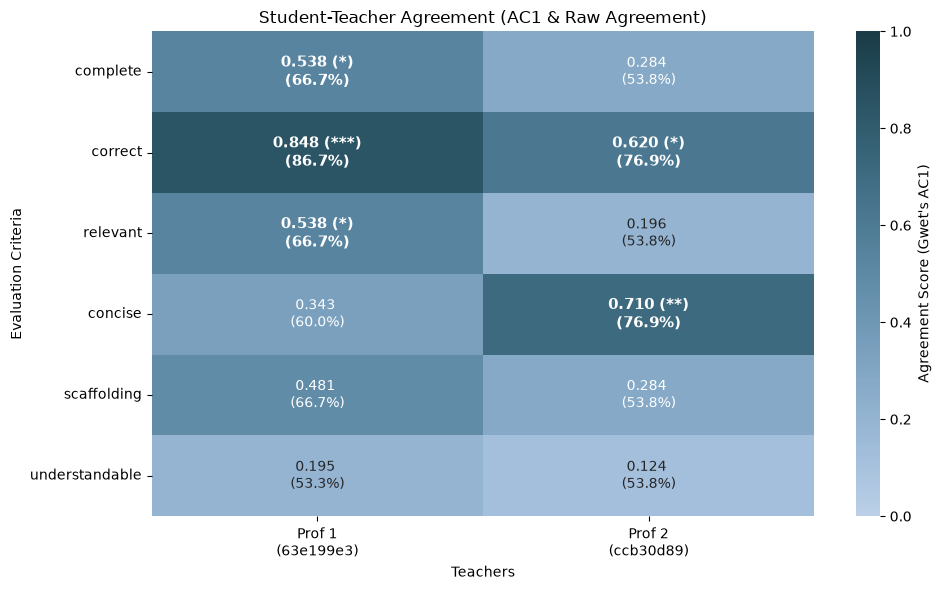

In [68]:
matrix, annotators = get_agreement_and_ac1_data()
for annotator in annotators:
    print(f"Annotator: {annotator}")
    for label in LABELS:
        agreement_data = matrix[label][annotator]
        print(f"Label: {label}".center(25) + f" | Raw Agreement: {agreement_data['raw_percent']:.2f}%".center(15) + f" | AC1: {agreement_data['ac1']:.3f}".center(10) + f" | p: {agreement_data['p_value']:.2e}".center(20))
    print("\n")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Tahoma', 'DejaVu Sans']
visualize_heatmap_ac1_and_agreement(matrix, annotators)

In [85]:
def get_llm_as_a_judge_annotations_list(jsonl_path: str) -> list[tuple[str, str, str]]:
    """
    - Parse the LLM-as-a-judge annotation JSON data and return it in a format suitable for bootstrapping analysis with BTD.
    - Ditch cases where at least one of the two positions is missing (_i.e._, only one of the two models was rated by the LLM-as-a-judge framework) -- preventing from taking into account position bias in the analysis.
    
    > [NOTE] _Addressing position swapping_ (An et al., 2025):
        - In the original LLM-as-a-judge paper (Zheng et al., 2023), it is advised to resolve inconsistencies in model ratings (_i.e._ cases when the LLM-as-a-judge framework rates the models inconsistently based on their position) with a tie.
        - However, because our rating model already allows for ties, this would inevitably skew the BTD parametres (nu in particular).
        - Hence, we integrate each of the swapped annotations into the final list. In that configuration, a win and a loss will be treated as roughly equivalent to a tie, giving more weight to annotations that are consistent across positions.
        
    Returns:
        A list of tuples (model_a, model_b, choice) where choice is 'a', 'b', or 'both_equal'
    """
    with open(jsonl_path, "r", encoding="utf-8") as f:
        records = [json.loads(line) for line in f]
        
    grouped = defaultdict(list)
    for r in records:
        key = (r.get("reaction_id"), r.get("annotator_id"))
        grouped[key].append(r)
    
    out = []
    
    for key, group in grouped.items():
        
        if len(group) != 2: # One of the two positions is missing, we skip this record
            print(f"Skipping record {key} due to missing a position.")
            continue
        
        for r in group:
            model_a = r.get("model_a_name", "")
            model_b = r.get("model_b_name", "")
            
            pref = r.get("judge_preferred_model", "")
            
            if not model_a or not model_b or not pref:
                print(f"Missing required fields in record: {r}")
                continue
            
            if pref == model_a:
                choice = 'a'
            elif pref == model_b:
                choice = 'b'
            elif pref == "both_equal":
                choice = 'both_equal'
            else:
                print(f"Invalid judge_preferred_model '{pref}' for models '{model_a}' and '{model_b}'. Expected one of: '{model_a}', '{model_b}', or 'both_equal'.")
                continue

            out.append((model_a, model_b, choice))

    print(f"Extracted {len(out)} annotations ({len(out) // 2} pairs) ready for analysis.")
    return out

def run_btd_pipeline_llm_as_a_judge(input_data_path: str, n_iterations: int = 1000, seed: int = 2026) -> tuple[list[float], float]:
    llm_annotations = get_llm_as_a_judge_annotations_list(input_data_path)

    llm_btd_scores, llm_nu = compute_btd_with_ci(llm_annotations, n_iterations=n_iterations, seed=seed)

    print(f"Estimated Davidson tie probability parameter (nu): {llm_nu:.3f}")
    visualize_btd_scores(llm_btd_scores)

    llm_pairwise_probs, llm_global_ewr = compute_win_probabilities(llm_btd_scores, llm_nu)
    llm_p_value_matrix, llm_stars_matrix = compute_significance_matrix(llm_btd_scores)

    print(" Pairwise Win Probabilities: ".center(60, '='))
    display(llm_pairwise_probs)
    
    print(" Global Expected Win Rates: ".center(60, '='))
    display(llm_global_ewr)
    
    print(" p-Value Matrix: ".center(60, '='))
    display(llm_p_value_matrix)
    
    print(" Significance Stars Matrix: ".center(60, '='))
    display(llm_stars_matrix)
    
    return llm_btd_scores, llm_nu

### Phi4 on the student conversation dataset

Skipping record (438, None) due to missing a position.
Skipping record (266, None) due to missing a position.
Extracted 94 annotations (47 pairs) ready for analysis.


Bootstrapping BTD: 100%|██████████| 1000/1000 [00:16<00:00, 61.84it/s]


Estimated Davidson tie probability parameter (nu): 1.307


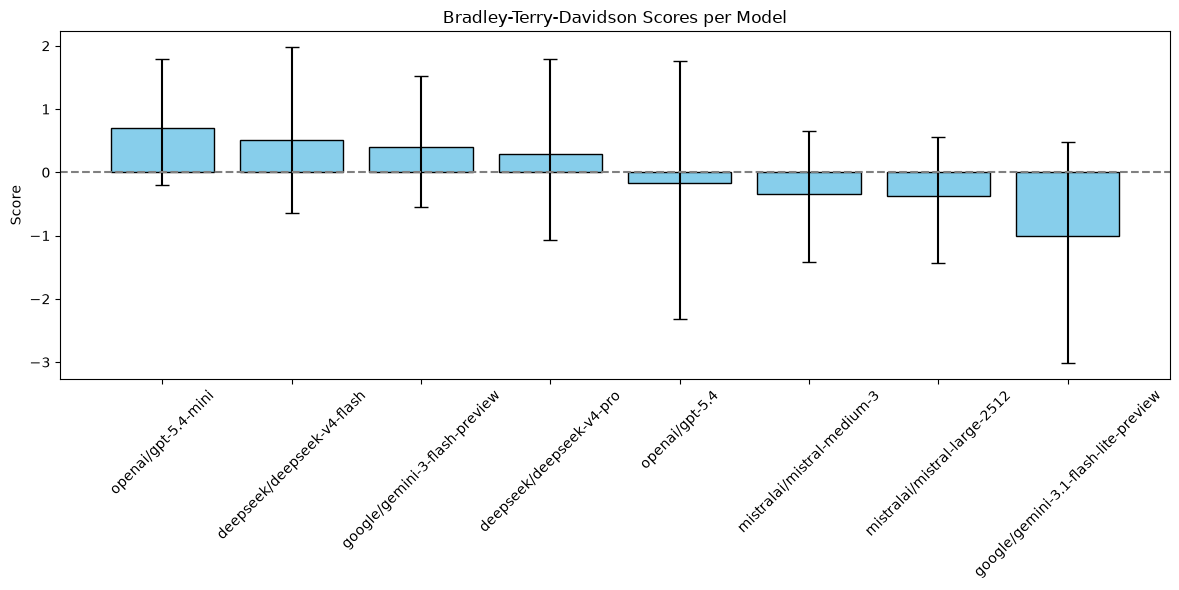

=============== Pairwise Win Probabilities: ================


,openai/gpt-5.4-mini,deepseek/deepseek-v4-flash,google/gemini-3-flash-preview,deepseek/deepseek-v4-pro,openai/gpt-5.4,mistralai/mistral-medium-3,mistralai/mistral-large-2512,google/gemini-3.1-flash-lite-preview
openai/gpt-5.4-mini,-,33.2%,34.8%,36.6%,44.0%,47.0%,47.4%,57.3%
deepseek/deepseek-v4-flash,27.4%,-,31.9%,33.6%,40.9%,43.9%,44.3%,54.4%
google/gemini-3-flash-preview,25.9%,28.7%,-,32.0%,39.2%,42.1%,42.5%,52.7%
deepseek/deepseek-v4-pro,24.3%,27.0%,28.6%,-,37.3%,40.3%,40.7%,50.9%
openai/gpt-5.4,18.6%,20.9%,22.3%,23.8%,-,33.0%,33.4%,43.5%
mistralai/mistral-medium-3,16.6%,18.7%,20.0%,21.4%,27.6%,-,30.6%,40.6%
mistralai/mistral-large-2512,16.3%,18.4%,19.7%,21.1%,27.2%,29.9%,-,40.2%
google/gemini-3.1-flash-lite-preview,10.5%,12.1%,13.0%,14.1%,18.9%,21.1%,21.4%,-


================ Global Expected Win Rates: ================


,Expected Global Win Rate
openai/gpt-5.4-mini,42.9%
deepseek/deepseek-v4-flash,39.5%
google/gemini-3-flash-preview,37.6%
deepseek/deepseek-v4-pro,35.6%
openai/gpt-5.4,27.9%
mistralai/mistral-medium-3,25.1%
mistralai/mistral-large-2512,24.7%
google/gemini-3.1-flash-lite-preview,15.9%


===================== p-Value Matrix: ======================


,openai/gpt-5.4-mini,deepseek/deepseek-v4-flash,google/gemini-3-flash-preview,deepseek/deepseek-v4-pro,openai/gpt-5.4,mistralai/mistral-medium-3,mistralai/mistral-large-2512,google/gemini-3.1-flash-lite-preview
openai/gpt-5.4-mini,-,4.240e-01,3.300e-01,2.960e-01,1.760e-01,5.200e-02,4.700e-02,2.900e-02
deepseek/deepseek-v4-flash,5.760e-01,-,4.130e-01,3.950e-01,2.610e-01,1.550e-01,1.240e-01,6.800e-02
google/gemini-3-flash-preview,6.700e-01,5.870e-01,-,4.290e-01,2.810e-01,1.700e-01,1.000e-01,6.500e-02
deepseek/deepseek-v4-pro,7.040e-01,6.050e-01,5.710e-01,-,3.510e-01,2.090e-01,2.210e-01,8.700e-02
openai/gpt-5.4,8.240e-01,7.390e-01,7.190e-01,6.490e-01,-,4.590e-01,4.620e-01,2.500e-01
mistralai/mistral-medium-3,9.480e-01,8.450e-01,8.300e-01,7.910e-01,5.410e-01,-,4.480e-01,1.910e-01
mistralai/mistral-large-2512,9.530e-01,8.760e-01,9.000e-01,7.790e-01,5.380e-01,5.520e-01,-,2.030e-01
google/gemini-3.1-flash-lite-preview,9.710e-01,9.320e-01,9.350e-01,9.130e-01,7.500e-01,8.090e-01,7.970e-01,-


================ Significance Stars Matrix: ================


,openai/gpt-5.4-mini,deepseek/deepseek-v4-flash,google/gemini-3-flash-preview,deepseek/deepseek-v4-pro,openai/gpt-5.4,mistralai/mistral-medium-3,mistralai/mistral-large-2512,google/gemini-3.1-flash-lite-preview
openai/gpt-5.4-mini,-,,,,,,*,*
deepseek/deepseek-v4-flash,,-,,,,,,
google/gemini-3-flash-preview,,,-,,,,,
deepseek/deepseek-v4-pro,,,,-,,,,
openai/gpt-5.4,,,,,-,,,
mistralai/mistral-medium-3,,,,,,-,,
mistralai/mistral-large-2512,,,,,,,-,
google/gemini-3.1-flash-lite-preview,,,,,,,,-


In [86]:
llm_phi4_reactions_scores, llm_phi4_reactions_nu = run_btd_pipeline_llm_as_a_judge(os.path.join("..", "data", "judge_runs", "reactions__phi4.jsonl"), n_iterations=1000)

### Qwen3-235B-A22B on the student conversation dataset

Extracted 98 annotations (49 pairs) ready for analysis.


Bootstrapping BTD: 100%|██████████| 1000/1000 [00:25<00:00, 39.70it/s]


Estimated Davidson tie probability parameter (nu): 0.535


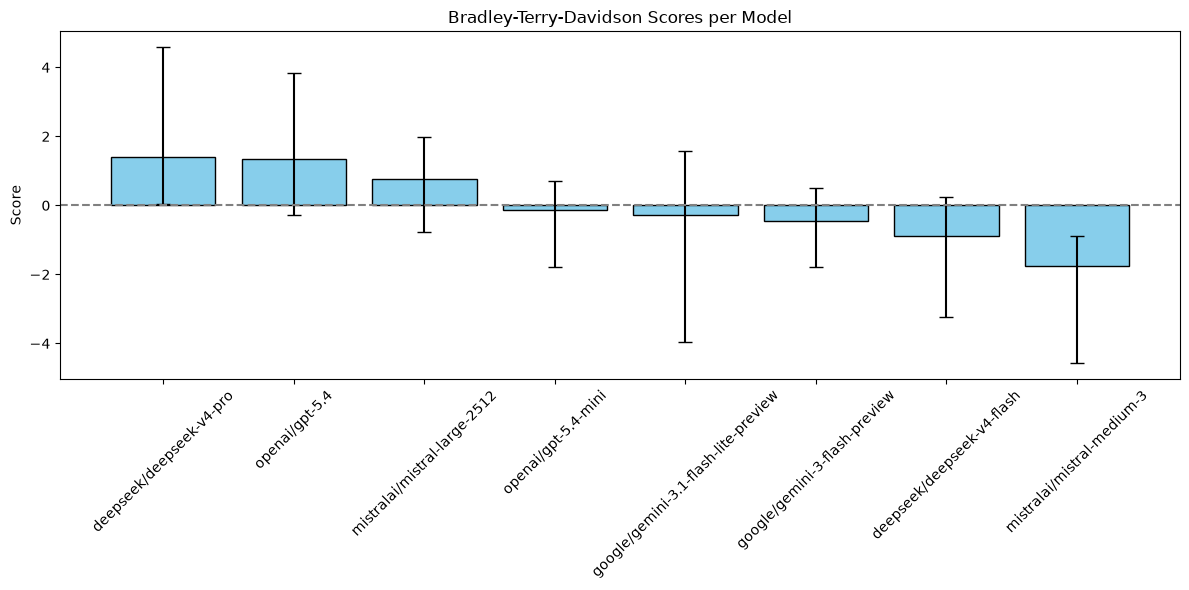

=============== Pairwise Win Probabilities: ================


,deepseek/deepseek-v4-pro,openai/gpt-5.4,mistralai/mistral-large-2512,openai/gpt-5.4-mini,google/gemini-3.1-flash-lite-preview,google/gemini-3-flash-preview,deepseek/deepseek-v4-flash,mistralai/mistral-medium-3
deepseek/deepseek-v4-pro,-,40.5%,52.2%,68.3%,70.6%,73.0%,78.6%,86.7%
openai/gpt-5.4,38.4%,-,51.1%,67.5%,69.8%,72.3%,78.0%,86.3%
mistralai/mistral-large-2512,27.5%,28.5%,-,57.2%,59.9%,62.9%,70.0%,81.0%
openai/gpt-5.4-mini,14.7%,15.3%,23.3%,-,42.4%,45.7%,54.3%,69.5%
google/gemini-3.1-flash-lite-preview,13.1%,13.7%,21.1%,36.6%,-,42.7%,51.4%,67.2%
google/gemini-3-flash-preview,11.5%,12.0%,18.8%,33.4%,36.2%,-,48.1%,64.4%
deepseek/deepseek-v4-flash,8.0%,8.4%,13.5%,25.7%,28.2%,31.1%,-,56.5%
mistralai/mistral-medium-3,3.7%,3.9%,6.6%,13.9%,15.6%,17.6%,23.9%,-


================ Global Expected Win Rates: ================


,Expected Global Win Rate
deepseek/deepseek-v4-pro,67.1%
openai/gpt-5.4,66.2%
mistralai/mistral-large-2512,55.3%
openai/gpt-5.4-mini,37.9%
google/gemini-3.1-flash-lite-preview,35.1%
google/gemini-3-flash-preview,32.1%
deepseek/deepseek-v4-flash,24.5%
mistralai/mistral-medium-3,12.2%


===================== p-Value Matrix: ======================


,deepseek/deepseek-v4-pro,openai/gpt-5.4,mistralai/mistral-large-2512,openai/gpt-5.4-mini,google/gemini-3.1-flash-lite-preview,google/gemini-3-flash-preview,deepseek/deepseek-v4-flash,mistralai/mistral-medium-3
deepseek/deepseek-v4-pro,-,4.960e-01,2.670e-01,2.600e-02,9.400e-02,1.700e-02,6.000e-03,0.000e+00
openai/gpt-5.4,5.040e-01,-,2.180e-01,2.700e-02,8.500e-02,7.000e-03,2.000e-03,0.000e+00
mistralai/mistral-large-2512,7.330e-01,7.820e-01,-,6.900e-02,1.170e-01,1.700e-02,5.000e-03,0.000e+00
openai/gpt-5.4-mini,9.740e-01,9.730e-01,9.310e-01,-,4.140e-01,2.670e-01,1.270e-01,2.000e-03
google/gemini-3.1-flash-lite-preview,9.060e-01,9.150e-01,8.830e-01,5.860e-01,-,4.410e-01,3.220e-01,1.180e-01
google/gemini-3-flash-preview,9.830e-01,9.930e-01,9.830e-01,7.330e-01,5.590e-01,-,2.070e-01,2.400e-02
deepseek/deepseek-v4-flash,9.940e-01,9.980e-01,9.950e-01,8.730e-01,6.780e-01,7.930e-01,-,1.030e-01
mistralai/mistral-medium-3,1.000e+00,1.000e+00,1.000e+00,9.980e-01,8.820e-01,9.760e-01,8.970e-01,-


================ Significance Stars Matrix: ================


,deepseek/deepseek-v4-pro,openai/gpt-5.4,mistralai/mistral-large-2512,openai/gpt-5.4-mini,google/gemini-3.1-flash-lite-preview,google/gemini-3-flash-preview,deepseek/deepseek-v4-flash,mistralai/mistral-medium-3
deepseek/deepseek-v4-pro,-,,,*,,*,**,***
openai/gpt-5.4,,-,,*,,**,**,***
mistralai/mistral-large-2512,,,-,,,*,**,***
openai/gpt-5.4-mini,,,,-,,,,**
google/gemini-3.1-flash-lite-preview,,,,,-,,,
google/gemini-3-flash-preview,,,,,,-,,*
deepseek/deepseek-v4-flash,,,,,,,-,
mistralai/mistral-medium-3,,,,,,,,-


In [87]:
llm_qwen3_235b_reactions_scores, llm_qwen3_235b_reactions_nu = run_btd_pipeline_llm_as_a_judge(os.path.join("..", "data", "judge_runs", "reactions__qwen3-235b.jsonl"), n_iterations=1000)

### Phi4 on the synthetic dataset

Skipping record (3803, 'd64b395a-6bca-466f-bf8a-53b7c778ba65') due to missing a position.
Skipping record (7851, 'd64b395a-6bca-466f-bf8a-53b7c778ba65') due to missing a position.
Extracted 508 annotations (254 pairs) ready for analysis.


Bootstrapping BTD:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping BTD: 100%|██████████| 1000/1000 [00:20<00:00, 48.41it/s]


Estimated Davidson tie probability parameter (nu): 1.087


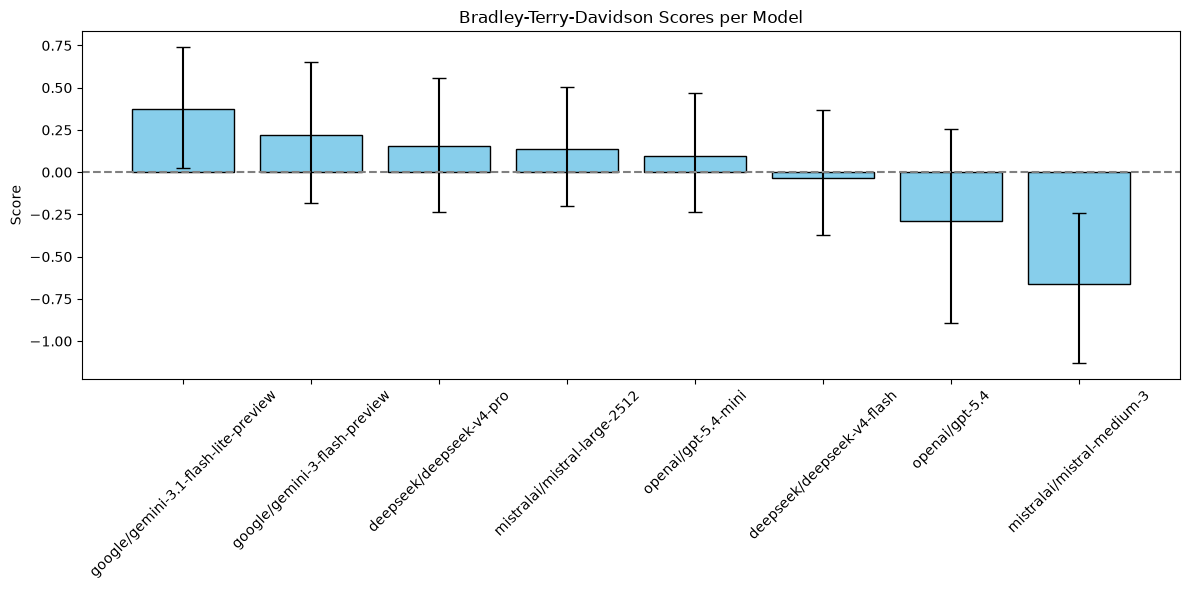

=============== Pairwise Win Probabilities: ================


,google/gemini-3.1-flash-lite-preview,google/gemini-3-flash-preview,deepseek/deepseek-v4-pro,mistralai/mistral-large-2512,openai/gpt-5.4-mini,deepseek/deepseek-v4-flash,openai/gpt-5.4,mistralai/mistral-medium-3
google/gemini-3.1-flash-lite-preview,-,35.0%,36.1%,36.3%,37.0%,39.2%,43.5%,49.9%
google/gemini-3-flash-preview,29.9%,-,33.5%,33.7%,34.4%,36.5%,40.9%,47.3%
deepseek/deepseek-v4-pro,28.9%,31.4%,-,32.7%,33.3%,35.5%,39.7%,46.2%
mistralai/mistral-large-2512,28.6%,31.1%,32.1%,-,33.1%,35.2%,39.5%,45.9%
openai/gpt-5.4-mini,28.0%,30.5%,31.5%,31.7%,-,34.5%,38.8%,45.2%
deepseek/deepseek-v4-flash,26.1%,28.4%,29.4%,29.7%,30.3%,-,36.6%,43.0%
openai/gpt-5.4,22.5%,24.7%,25.6%,25.8%,26.4%,28.4%,-,38.6%
mistralai/mistral-medium-3,17.7%,19.6%,20.4%,20.7%,21.2%,22.9%,26.6%,-


================ Global Expected Win Rates: ================


,Expected Global Win Rate
google/gemini-3.1-flash-lite-preview,39.6%
google/gemini-3-flash-preview,36.6%
deepseek/deepseek-v4-pro,35.4%
mistralai/mistral-large-2512,35.1%
openai/gpt-5.4-mini,34.3%
deepseek/deepseek-v4-flash,31.9%
openai/gpt-5.4,27.4%
mistralai/mistral-medium-3,21.3%


===================== p-Value Matrix: ======================


,google/gemini-3.1-flash-lite-preview,google/gemini-3-flash-preview,deepseek/deepseek-v4-pro,mistralai/mistral-large-2512,openai/gpt-5.4-mini,deepseek/deepseek-v4-flash,openai/gpt-5.4,mistralai/mistral-medium-3
google/gemini-3.1-flash-lite-preview,-,2.920e-01,2.260e-01,1.770e-01,1.470e-01,6.900e-02,4.300e-02,1.000e-03
google/gemini-3-flash-preview,7.080e-01,-,4.170e-01,3.690e-01,3.260e-01,1.930e-01,9.200e-02,1.000e-03
deepseek/deepseek-v4-pro,7.740e-01,5.830e-01,-,4.460e-01,4.130e-01,2.610e-01,1.300e-01,6.000e-03
mistralai/mistral-large-2512,8.230e-01,6.310e-01,5.540e-01,-,4.540e-01,2.930e-01,1.290e-01,4.000e-03
openai/gpt-5.4-mini,8.530e-01,6.740e-01,5.870e-01,5.460e-01,-,3.100e-01,1.580e-01,5.000e-03
deepseek/deepseek-v4-flash,9.310e-01,8.070e-01,7.390e-01,7.070e-01,6.900e-01,-,2.480e-01,1.100e-02
openai/gpt-5.4,9.570e-01,9.080e-01,8.700e-01,8.710e-01,8.420e-01,7.520e-01,-,1.870e-01
mistralai/mistral-medium-3,9.990e-01,9.990e-01,9.940e-01,9.960e-01,9.950e-01,9.890e-01,8.130e-01,-


================ Significance Stars Matrix: ================


,google/gemini-3.1-flash-lite-preview,google/gemini-3-flash-preview,deepseek/deepseek-v4-pro,mistralai/mistral-large-2512,openai/gpt-5.4-mini,deepseek/deepseek-v4-flash,openai/gpt-5.4,mistralai/mistral-medium-3
google/gemini-3.1-flash-lite-preview,-,,,,,,*,***
google/gemini-3-flash-preview,,-,,,,,,***
deepseek/deepseek-v4-pro,,,-,,,,,**
mistralai/mistral-large-2512,,,,-,,,,**
openai/gpt-5.4-mini,,,,,-,,,**
deepseek/deepseek-v4-flash,,,,,,-,,*
openai/gpt-5.4,,,,,,,-,
mistralai/mistral-medium-3,,,,,,,,-


In [88]:
llm_profs_phase2_phi4_scores, llm_profs_phase2_phi4_nu = run_btd_pipeline_llm_as_a_judge(os.path.join("..", "data", "judge_runs", "profs_phase2__phi4.jsonl"), n_iterations=1000)

### Qwen3-235B-A22B on the synthetic dataset

Extracted 512 annotations (256 pairs) ready for analysis.


Bootstrapping BTD: 100%|██████████| 1000/1000 [00:23<00:00, 43.13it/s]


Estimated Davidson tie probability parameter (nu): 1.366


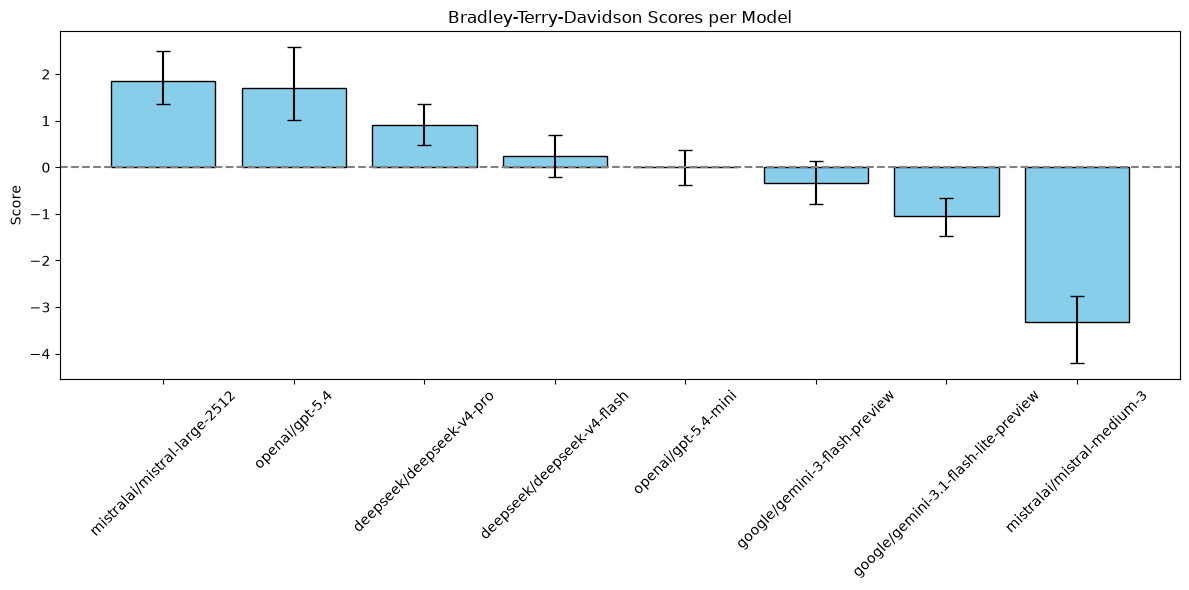

=============== Pairwise Win Probabilities: ================


,mistralai/mistral-large-2512,openai/gpt-5.4,deepseek/deepseek-v4-pro,deepseek/deepseek-v4-flash,openai/gpt-5.4-mini,google/gemini-3-flash-preview,google/gemini-3.1-flash-lite-preview,mistralai/mistral-medium-3
mistralai/mistral-large-2512,-,31.8%,44.4%,55.3%,58.9%,63.8%,72.5%,90.2%
openai/gpt-5.4,27.7%,-,42.2%,53.1%,56.8%,61.9%,70.9%,89.5%
deepseek/deepseek-v4-pro,17.5%,19.1%,-,40.4%,44.2%,49.8%,60.4%,84.9%
deepseek/deepseek-v4-flash,11.0%,12.2%,20.4%,-,33.3%,38.8%,49.9%,79.4%
openai/gpt-5.4-mini,9.2%,10.3%,17.6%,26.3%,-,35.0%,46.1%,77.2%
google/gemini-3-flash-preview,7.1%,7.9%,14.1%,21.7%,24.8%,-,40.5%,73.6%
google/gemini-3.1-flash-lite-preview,4.0%,4.6%,8.6%,14.0%,16.4%,20.3%,-,65.0%
mistralai/mistral-medium-3,0.5%,0.6%,1.2%,2.3%,2.8%,3.8%,6.6%,-


================ Global Expected Win Rates: ================


,Expected Global Win Rate
mistralai/mistral-large-2512,59.6%
openai/gpt-5.4,57.4%
deepseek/deepseek-v4-pro,45.2%
deepseek/deepseek-v4-flash,35.0%
openai/gpt-5.4-mini,31.7%
google/gemini-3-flash-preview,27.1%
google/gemini-3.1-flash-lite-preview,19.0%
mistralai/mistral-medium-3,2.5%


===================== p-Value Matrix: ======================


,mistralai/mistral-large-2512,openai/gpt-5.4,deepseek/deepseek-v4-pro,deepseek/deepseek-v4-flash,openai/gpt-5.4-mini,google/gemini-3-flash-preview,google/gemini-3.1-flash-lite-preview,mistralai/mistral-medium-3
mistralai/mistral-large-2512,-,3.840e-01,5.000e-03,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
openai/gpt-5.4,6.160e-01,-,5.200e-02,2.000e-03,0.000e+00,0.000e+00,0.000e+00,0.000e+00
deepseek/deepseek-v4-pro,9.950e-01,9.480e-01,-,1.500e-02,0.000e+00,0.000e+00,0.000e+00,0.000e+00
deepseek/deepseek-v4-flash,1.000e+00,9.980e-01,9.850e-01,-,2.170e-01,4.100e-02,0.000e+00,0.000e+00
openai/gpt-5.4-mini,1.000e+00,1.000e+00,1.000e+00,7.830e-01,-,1.340e-01,1.000e-03,0.000e+00
google/gemini-3-flash-preview,1.000e+00,1.000e+00,1.000e+00,9.590e-01,8.660e-01,-,1.900e-02,0.000e+00
google/gemini-3.1-flash-lite-preview,1.000e+00,1.000e+00,1.000e+00,1.000e+00,9.990e-01,9.810e-01,-,0.000e+00
mistralai/mistral-medium-3,1.000e+00,1.000e+00,1.000e+00,1.000e+00,1.000e+00,1.000e+00,1.000e+00,-


================ Significance Stars Matrix: ================


,mistralai/mistral-large-2512,openai/gpt-5.4,deepseek/deepseek-v4-pro,deepseek/deepseek-v4-flash,openai/gpt-5.4-mini,google/gemini-3-flash-preview,google/gemini-3.1-flash-lite-preview,mistralai/mistral-medium-3
mistralai/mistral-large-2512,-,,**,***,***,***,***,***
openai/gpt-5.4,,-,,**,***,***,***,***
deepseek/deepseek-v4-pro,,,-,*,***,***,***,***
deepseek/deepseek-v4-flash,,,,-,,*,***,***
openai/gpt-5.4-mini,,,,,-,,***,***
google/gemini-3-flash-preview,,,,,,-,*,***
google/gemini-3.1-flash-lite-preview,,,,,,,-,***
mistralai/mistral-medium-3,,,,,,,,-


In [89]:
llm_profs_phase2_qwen3_235b_scores, llm_profs_phase2_qwen3_235b_nu = run_btd_pipeline_llm_as_a_judge(os.path.join("..", "data", "judge_runs", "profs_phase2__qwen3-235b.jsonl"), n_iterations=1000)

### Rank correlation between human- and LLM-estimated BTD logit scores

In [97]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def compute_probabilistic_correlations(human_btd_scores: dict, llm_btd_scores: dict, model_name: str, n_iterations: int = 10000, seed: int = 2026) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute Spearman and Kendall correlations while accounting for the uncertainty of the BTD scores via a Monte Carlo simulation on the bootstrap arrays.
    
    Parameters:
        human_btd_scores (dict): BTD scores for human annotations, including bootstrapped scores.
        llm_btd_scores (dict): BTD scores for LLM-as-a-judge annotations, including bootstrapped scores.
        n_iterations (int): Number of Monte Carlo iterations
        seed (int): Random seed for reproducibility
    
    """
    models = list(human_btd_scores.keys())
    
    spearman_corrs = []
    kendall_corrs = []
    
    n_human_samples = len(human_btd_scores[models[0]]["bootstrapped_scores_array"])
    n_llm_samples = len(llm_btd_scores[models[0]]["bootstrapped_scores_array"])
    
    rng = np.random.default_rng(seed)
    
    for _ in tqdm(range(n_iterations), desc="Monte-Carlo Correlations"):
        # Random sampling of indices for humans and LLMs
        h_idx = rng.integers(0, n_human_samples)
        l_idx = rng.integers(0, n_llm_samples)
        
        # Reconstruct scores from raw logits for this iteration
        h_scores = [human_btd_scores[m]["bootstrapped_scores_array"][h_idx] for m in models]
        l_scores = [llm_btd_scores[m]["bootstrapped_scores_array"][l_idx] for m in models]
        
        # Ignore iterations containing NaN
        if np.isnan(h_scores).any() or np.isnan(l_scores).any():
            continue
            
        # Compute Spearman and Kendall correlations for this specific draw
        s_corr, _ = stats.spearmanr(h_scores, l_scores)
        k_corr, _ = stats.kendalltau(h_scores, l_scores)
        
        spearman_corrs.append(s_corr)
        kendall_corrs.append(k_corr)
        
    spearman_corrs = np.array(spearman_corrs)
    kendall_corrs = np.array(kendall_corrs)
    
    # Extract median and 95% confidence intervals for both Spearman and Kendall correlations
    def get_stats(arr):
        return {
            "median": np.median(arr),
            "ci_lower": np.percentile(arr, 2.5),
            "ci_upper": np.percentile(arr, 97.5)
        }
        
    stats_spearman = get_stats(spearman_corrs)
    stats_kendall = get_stats(kendall_corrs)
    
    print("="*50)
    print(f"Spearman's Rho: {stats_spearman['median']:.3f} CI 95% [{stats_spearman['ci_lower']:.3f}, {stats_spearman['ci_upper']:.3f}]")
    print(f"Kendall's Tau: {stats_kendall['median']:.3f} CI 95% [{stats_kendall['ci_lower']:.3f}, {stats_kendall['ci_upper']:.3f}]")
    print("="*50)
    
    # Dataviz
    plt.figure(figsize=(10, 6))
    
    # Spearman curve (Blue)
    sns.kdeplot(spearman_corrs, fill=True, color="#1f77b4", alpha=0.4, label=f"Spearman's Rho (Median: {stats_spearman['median']:.2f})")
    plt.axvline(stats_spearman['median'], color="#1f77b4", linestyle="-")
    
    # Kendall curve (Orange)
    sns.kdeplot(kendall_corrs, fill=True, color="#ff7f0e", alpha=0.4, label=f"Kendall's Tau (Median: {stats_kendall['median']:.2f})")
    plt.axvline(stats_kendall['median'], color="#ff7f0e", linestyle="-")
    
    # Zero line (no correlation) for reference
    plt.axvline(0, color="gray", linestyle=":", linewidth=2, label="Absolute independence")
    
    plt.title(f"Probabilistic Distribution of Human vs LLM Alignment ({model_name})")
    plt.xlabel("Correlation Coefficient")
    plt.ylabel("Probability Density (Monte-Carlo)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return spearman_corrs, kendall_corrs

Monte-Carlo Correlations: 100%|██████████| 10000/10000 [00:03<00:00, 2985.42it/s]


Spearman's Rho: -0.095 CI 95% [-0.714, 0.643]
Kendall's Tau: -0.071 CI 95% [-0.571, 0.500]


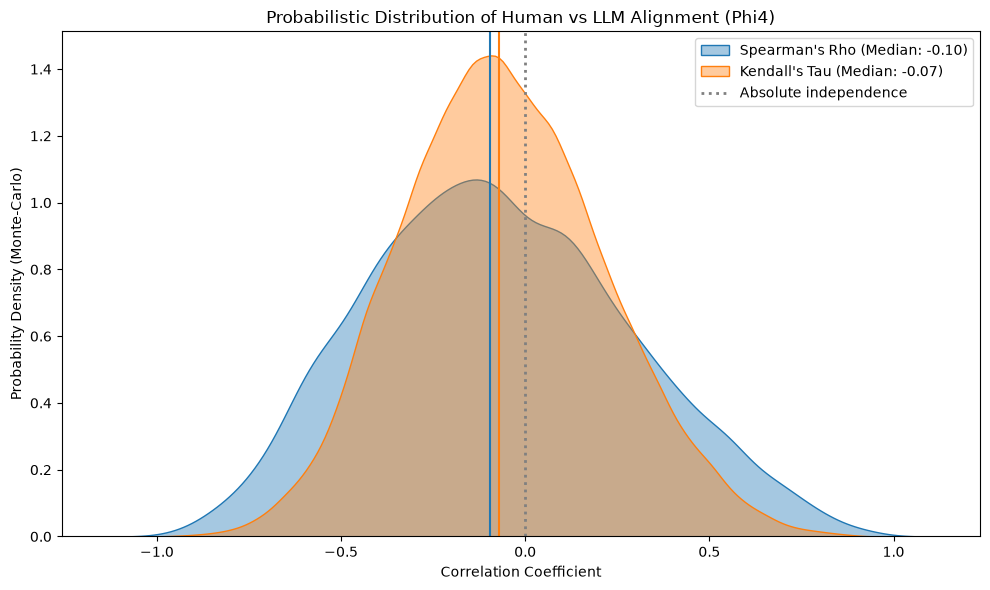

In [98]:
spearman_dist, kendall_dist = compute_probabilistic_correlations(btd_scores, llm_phi4_reactions_scores, model_name="Phi4", n_iterations=10000)

Monte-Carlo Correlations: 100%|██████████| 10000/10000 [00:03<00:00, 3177.60it/s]


Spearman's Rho: 0.119 CI 95% [-0.500, 0.643]
Kendall's Tau: 0.071 CI 95% [-0.357, 0.500]


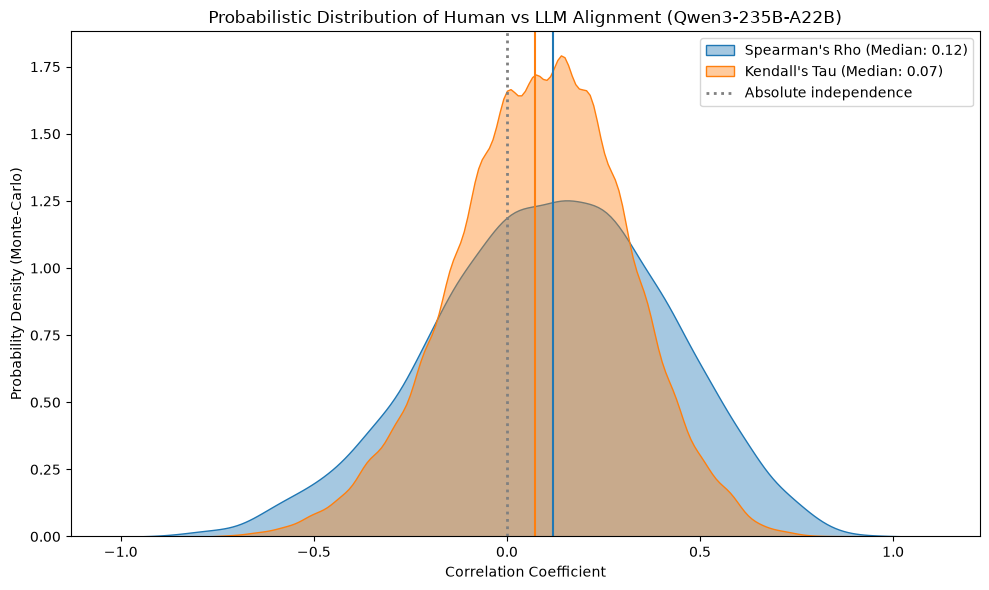

In [99]:
spearman_dist, kendall_dist = compute_probabilistic_correlations(btd_scores, llm_qwen3_235b_reactions_scores, model_name="Qwen3-235B-A22B", n_iterations=10000)

- do the experts agree between each other concerning the labels?
- did we exclude items where students put false everywhere?
- who says yes/no when labels diverge between students and experts?
- despite being given a "tie" option (cf. central tendency bias), annotators took a definite stance in xx% of cases

- compute btd for student ratings
- compare btd with star ratings

===

- observations/limites :
    - clustering de postures pédagogiques sur l'évaluation => plutôt que d'avoir une seule note générique, on la conditionne à une certaine posture
    - calibrer la notation sur le consensus, et faire les experts se réunir pour discuter des cas divergents
    - vérifier l'indépendance des variables en fonction de la langue ou du thème d'affichage